In [1]:
In [1]: #import all the necessary packages.

from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
import math
import time
import re
import os
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances
from matplotlib import gridspec
from scipy.sparse import hstack
import plotly
import plotly.figure_factory as ff
from plotly.graph_objs import Scatter, Layout

plotly.offline.init_notebook_mode(connected=True)
warnings.filterwarnings("ignore")

In [2]:
# we have give a json file which consists of all information about
        # the products
        # loading the data using pandas' read_json file.
data = pd.read_json("marketing_sample_for_amazon_com-amazon_fashion_products__20200201_20200430__30k_data.ldjson", lines=True)
print(data.head())

                            uniq_id            crawl_timestamp        asin  \
0  26d41bdc1495de290bc8e6062d927729  2020-02-07 05:11:36 +0000  B07STS2W9T   
1  410c62298852e68f34c35560f2311e5a  2020-02-07 08:45:56 +0000  B07N6TD2WL   
2  52e31bb31680b0ec73de0d781a23cc0a  2020-02-06 11:09:38 +0000  B07WJ6WPN1   
3  25798d6dc43239c118452d1bee0fb088  2020-02-07 08:32:45 +0000  B07PYSF4WZ   
4  ad8a5a196d515ef09dfdaf082bdc37c4  2020-02-06 14:27:48 +0000  B082KXNM7X   

                                         product_url  \
0  https://www.amazon.in/Facon-Kalamkari-Handbloc...   
1  https://www.amazon.in/Sf-Jeans-Pantaloons-T-Sh...   
2  https://www.amazon.in/LOVISTA-Traditional-Prin...   
3  https://www.amazon.in/People-Printed-Regular-T...   
4  https://www.amazon.in/Monte-Carlo-Cotton-Colla...   

                                        product_name  \
0  LA' Facon Cotton Kalamkari Handblock Saree Blo...   
1  Sf Jeans By Pantaloons Men's Plain Slim fit T-...   
2  LOVISTA Cotton Gota Pat

In [3]:
print('Number of data points:',data.shape[0],'Number of features:',data.shape[1])

Number of data points: 30000 Number of features: 33


In [4]:
data.head()

,uniq_id,crawl_timestamp,asin,product_url,product_name,image_urls__small,medium,large,browsenode,brand,...,colour,no__of_reviews,seller_name,seller_id,left_in_stock,no__of_offers,no__of_sellers,technical_details__k_v_pairs,formats___editions,name_of_author_for_books
0,26d41bdc1495de290bc8e6062d927729,2020-02-07 05:11:36 +0000,B07STS2W9T,https://www.amazon.in/Facon-Kalamkari-Handbloc...,LA' Facon Cotton Kalamkari Handblock Saree Blo...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968255e+09,LA' Facon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,410c62298852e68f34c35560f2311e5a,2020-02-07 08:45:56 +0000,B07N6TD2WL,https://www.amazon.in/Sf-Jeans-Pantaloons-T-Sh...,Sf Jeans By Pantaloons Men's Plain Slim fit T-...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968123e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,52e31bb31680b0ec73de0d781a23cc0a,2020-02-06 11:09:38 +0000,B07WJ6WPN1,https://www.amazon.in/LOVISTA-Traditional-Prin...,LOVISTA Cotton Gota Patti Tassel Traditional P...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968255e+09,LOVISTA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25798d6dc43239c118452d1bee0fb088,2020-02-07 08:32:45 +0000,B07PYSF4WZ,https://www.amazon.in/People-Printed-Regular-T...,People Men's Printed Regular fit T-Shirt,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968123e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ad8a5a196d515ef09dfdaf082bdc37c4,2020-02-06 14:27:48 +0000,B082KXNM7X,https://www.amazon.in/Monte-Carlo-Cotton-Colla...,Monte Carlo Grey Solid Cotton Blend Polo Colla...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968070e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print(data['product_name'].describe())

count                           30000
unique                          22424
top       BIBA Women's Straight Kurta
freq                               70
Name: product_name, dtype: object


In [6]:
print(data['product_name'].unique())

<StringArray>
[                                                                                      'LA' Facon Cotton Kalamkari Handblock Saree Blouse Fabric 100 cms Black Base Dancers (Cotton)',
                                                                                                                                'Sf Jeans By Pantaloons Men's Plain Slim fit T-Shirt',
                                                                                          'LOVISTA Cotton Gota Patti Tassel Traditional Printed Kurti with Pant,Angrakha Salwar Suit',
                                                                                                                                           'People Men's Printed Regular fit T-Shirt',
                                                                                                                          'Monte Carlo Grey Solid Cotton Blend Polo Collar Tracksuit',
                                                   'Forest Club | Gym W

In [7]:
product_type_count=Counter(list(data['product_name']))
product_type_count.most_common(16)

[("BIBA Women's Straight Kurta", 70),
 ('W for Woman Straight Kurta', 63),
 ("W for Woman Women's Straight Kurta", 55),
 ("W for Women's Straight Kurta", 47),
 ("Aurelia Women's Straight Kurta", 43),
 ("Max Boy's Regular fit T-Shirt", 42),
 ("Soch Women's Straight Kurta", 41),
 ("Excalibur by Unlimited Men's Solid Regular Fit Formal Shirt (Pack of 2)(Colors & Print May Vary)",
  40),
 ("Max Boy's Regular Fit T-Shirt", 39),
 ("Aurelia Women's Straight Fit Kurta", 39),
 ("Peter England Men's Plain Slim Fit Formal Shirt", 37),
 ("Rangriti Women's Straight Kurta", 34),
 ("People Men's Regular fit T-Shirt", 33),
 ("Peter England Men's Slim fit Formal Shirt", 30),
 ("Max Girl's Regular Fit T-Shirt", 30),
 ("Jack & Jones Men's T-Shirt", 30)]

In [8]:
print(data['brand'].describe())

count     21857
unique     6458
top         Max
freq        504
Name: brand, dtype: object


In [9]:
brand_count=Counter(list(data['brand']))
brand_count.most_common(16)

[(nan, 8143),
 ('Max', 504),
 ('Generic', 245),
 ('BIBA', 205),
 ('Mothercare', 156),
 ('Campus Sutra', 150),
 ('Soch', 149),
 ('nauti nati', 132),
 ('Ada', 127),
 ('GRITSTONES', 110),
 ('PrintOctopus', 102),
 ('Allen Solly Junior', 93),
 ('Columbia', 92),
 ('Excalibur by Unlimited', 80),
 ('Indian Terrain', 80),
 ('ANNI DESIGNER', 78)]

In [10]:
print(data['colour'].describe())

count            6029
unique           4757
top       Black|White
freq               79
Name: colour, dtype: object


In [11]:
brand_count=Counter(list(data['colour']))
brand_count.most_common(16)

[(nan, 23971),
 ('Black|White', 79),
 ('Black|Blue', 45),
 ('Black|Red', 34),
 ('Black|Navy', 31),
 ('Blue|Red', 30),
 ('Black|Navy Blue', 21),
 ('Blue|Pink', 21),
 ('Black|Grey', 21),
 ('White|Black', 20),
 ('White|Yellow', 19),
 ('Black|Blue|Red', 18),
 ('Green|Red', 17),
 ('Blue|Yellow', 15),
 ('Pink|Red', 15),
 ('Brown|Black', 15)]

In [12]:
print(data.columns)


Index(['uniq_id', 'crawl_timestamp', 'asin', 'product_url', 'product_name',
       'image_urls__small', 'medium', 'large', 'browsenode', 'brand',
       'sales_price', 'weight', 'rating', 'sales_rank_in_parent_category',
       'sales_rank_in_child_category', 'delivery_type', 'meta_keywords',
       'amazon_prime__y_or_n', 'parent___child_category__all',
       'best_seller_tag__y_or_n', 'other_items_customers_buy',
       'product_details__k_v_pairs', 'discount_percentage', 'colour',
       'no__of_reviews', 'seller_name', 'seller_id', 'left_in_stock',
       'no__of_offers', 'no__of_sellers', 'technical_details__k_v_pairs',
       'formats___editions', 'name_of_author_for_books'],
      dtype='str')


In [13]:
print(data['rating'].describe())

count    30000.000000
mean         4.039857
std          0.840009
min          1.000000
25%          3.500000
50%          4.000000
75%          4.900000
max          5.000000
Name: rating, dtype: float64


In [14]:
brand_count=Counter(list(data['rating']))
brand_count.most_common(16)

[(5.0, 7450),
 (4.0, 3861),
 (3.0, 1802),
 (4.5, 1403),
 (3.9, 1142),
 (3.5, 1140),
 (3.8, 1068),
 (3.7, 1041),
 (3.6, 998),
 (3.4, 940),
 (4.1, 936),
 (4.2, 897),
 (4.3, 887),
 (4.6, 879),
 (4.4, 844),
 (3.3, 791)]

In [15]:
print(data['technical_details__k_v_pairs'].describe())

count                                                  1154
unique                                                 1122
top       {'Batteries_Included': 'No', 'Brand': 'FEIQIAO...
freq                                                      6
Name: technical_details__k_v_pairs, dtype: object


In [16]:
def get_brand(x):
    # Case 1: if value is a dictionary
    if isinstance(x, dict):
        return x.get('Brand')

    # Case 2: if value is a string
    if isinstance(x, str):
        parts = x.split(',')
        for p in parts:
            if 'Brand' in p:
                return p.split(':')[-1].strip()

    return None



In [17]:
from collections import Counter

brands = data['technical_details__k_v_pairs'].apply(get_brand)

brand_count = Counter(brands.dropna())

print(brand_count.most_common(16))


[('Columbia', 57), ('Speedo', 30), ('Augusta Sportswear', 24), ('Kobo', 12), ('Vector X', 12), ('TruForm', 12), ('Casotec', 11), ('Romano', 10), ('Shock Doctor', 10), ('Gajraj', 9), ('Chevrolet', 7), ('Noise', 7), ('Alpinestars', 7), ('Nivia', 6), ('Harbinger', 6), ('FEIQIAOSH', 6)]


In [18]:
data.dtypes
print(type(data.iloc[0]))



<class 'pandas.Series'>


In [19]:
#data.to_pickle('pickle/100k_apparel_data')

In [20]:
#to check data set which having price is null
data=data.loc[-data['sales_price'].isnull()]
print('Number of data points after eliminating price=NULL:',data.shape[0])

Number of data points after eliminating price=NULL: 27110


In [21]:
#for colour information is null
data=data.loc[-data['colour'].isnull()]
print('Number of data points after eliminating colour=NULL:',data.shape[0])

Number of data points after eliminating colour=NULL: 5825


In [22]:
data.to_pickle('amazon_data.pkl')
data=pd.read_pickle('amazon_data.pkl')

In [23]:
#remove duplicate colour
#like sizes are are of same colour
data=pd.read_pickle('amazon_data.pkl')
print(sum(data.duplicated('product_details__k_v_pairs')))

147


In [24]:
data.head()

,uniq_id,crawl_timestamp,asin,product_url,product_name,image_urls__small,medium,large,browsenode,brand,...,colour,no__of_reviews,seller_name,seller_id,left_in_stock,no__of_offers,no__of_sellers,technical_details__k_v_pairs,formats___editions,name_of_author_for_books
5,73fd23f631d4434fd4a41ecc1b9f5eed,2020-02-06 08:14:03 +0000,B07X5M41BJ,https://www.amazon.in/Forest-Club-Sports-Breat...,Forest Club | Gym Wear | Sports Shorts| Shorts...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968097e+09,Forest Club,...,Black|Blue|Grey,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,14d7d34c3cacd6c9ed1aa57f284e37ad,2020-02-06 04:00:23 +0000,B07H9RCVHQ,https://www.amazon.in/Graphic-Printed-T-Shirt-...,PrintOctopus Graphic Printed T-Shirt for Men C...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968123e+09,PrintOctopus,...,Black|Navy Blue,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,46005e6f4f253e551ede9b580cf83b73,2020-02-06 08:56:32 +0000,B083ZKXVGN,https://www.amazon.in/Miss-Chase-Womens-Cut-Ou...,Miss Chase Women's Solid Shoulder Cut-Out Half...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968445e+09,Miss Chase,...,Black|Maroon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,2b1c8bedb40220c7312f0edeea2a31d2,2020-02-06 19:58:48 +0000,B07K6PHHHM,https://www.amazon.in/PuJoy-Womens-Traditional...,PuJoy Women's Soft Cotton Traditional Bengali ...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968256e+09,PuJoy,...,Black Based|Black Based 2|Black White|Blue Whi...,NaN,PuJoy Textile,ALBGM8FFNXZK2,3.0,NaN,NaN,NaN,NaN,NaN
22,8c8ef13b817747710eae99c1718c9be9,2020-02-06 20:30:56 +0000,B0759HPKCJ,https://www.amazon.in/Kalpit-Comfort-Premium-C...,kalpit creations Men's Comfort Soft Cotton Bla...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968122e+09,kalpit creations,...,Black|Bottle green|GREEN|NAVY BLUE|Pink|Red|WH...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
data_sorted = data[
    data['product_details__k_v_pairs'].notna() &
    data['product_details__k_v_pairs'].apply(
        lambda x: isinstance(x, str) and len(x.strip().split()) > 4
    )
]


In [26]:
data_sorted = data[
    data['product_details__k_v_pairs']
    .fillna('')
    .astype(str)
    .apply(lambda x: len(x.split()) > 4)
]


In [27]:
indices=[]
for i,row in data_sorted.iterrows():
    indices.append(i)

In [28]:
import itertools
stage1_dedupe_asins=[]
i=0
j=0
num_data_points=data_sorted.shape[0]
while i<num_data_points and j<num_data_points:
    previous_i=i
    a=data['product_name'].loc[indices[i]].split()
    j=i+1
    while j<num_data_points:
        b=data['product_name'].loc[indices[j]].split()
        length=max(len(a),len(b))
        count=0
        for k in itertools.zip_longest(a,b):
            if(k[0]==k[1]):
                count +=1
        if(length-count)>2:
            stage1_dedupe_asins.append(data_sorted['asin'].loc[indices[i]])
            if j==num_data_points-1: stage1_dedupe_asins.append(data_sorted['asin'].loc[indices[i]])
            i=j
            break
        else:
            j +=1
    if previous_i==i:
        break
        

In [29]:
data=data.loc[data['asin'].isin(stage1_dedupe_asins)]

In [30]:
#we removed the duplicates which differ only at the end.
print('number of data points :',data.shape[0])

number of data points : 5697


In [31]:
data.to_pickle('amazon_data.pkl')

In [32]:
data=pd.read_pickle('amazon_data.pkl')

In [33]:
import itertools

# Use the index from your sorted dataframe
indices = list(data_sorted.index)
stage2_dedupe_asins = []

while indices:
    # Pop from the end (fastest in Python lists)
    i = indices.pop()
    
    # Store the ASIN of the unique item we are keeping
    stage2_dedupe_asins.append(data_sorted.at[i, 'asin'])

    # Pre-split the anchor product name
    val_a = data_sorted.at[i, 'product_name']
    a = str(val_a).split() if val_a is not None else []

    to_remove = []

    for j in indices:
        b_val = data_sorted.at[j, 'product_name']

        # Skip if name is missing
        if not isinstance(b_val, str):
            continue

        b = b_val.split()

        # Positional matching logic
        length = max(len(a), len(b))
        count = sum(1 for x, y in itertools.zip_longest(a, b) if x == y)

        # Check if difference is small enough to be a duplicate
        if (length - count) < 3:
            to_remove.append(j)

    # Convert to set for O(1) lookup speed during removal
    to_remove_set = set(to_remove)
    indices = [idx for idx in indices if idx not in to_remove_set]

print("Final unique products:", len(stage2_dedupe_asins))


Final unique products: 3758


In [34]:
indices=[]
#for i,row in data_sorted.iterrows():
 #   indices.append(i)
indices=list(data_sorted.index)
stage2_dedupe_asins=[]
while len(indices)!=0:
    i=indices.pop()
    stage2_dedupe_asins.append(data_sorted.at[i,'asin'])
    a=str(data_sorted.at[i,'product_name']).split()
    for j in indices:
        b=data_sorted.at[j,'product_name'].split()
        length=max(len(a),len(b))
        count=0
        for k in itertools.zip_longest(a,b):
            if(k[0]==k[1]):
                count+=1
        if(length-count)<3:
            indices.remove(j)


In [35]:
data=data.loc[data['asin'].isin(stage2_dedupe_asins)]

In [36]:
print('Number of data points after stage two of dedupes:',data.shape[0])

Number of data points after stage two of dedupes: 3870


In [37]:
#text pre-processing
data=pd.read_pickle('amazon_data.pkl')

In [38]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words=set(ENGLISH_STOP_WORDS)
print('list of stop words:',stop_words)
def nlp_preprocessing(total_text,index,column):
    if not isinstance(total_text, int):
        string=""
        for words in total_text.split():
            word=("".join(e for e in words if e.isalnum()))
            word=word.lower()
            if not word in stop_words:
                string+=word+" "
        data.at[index,column]=string.strip()
        

list of stop words: {'there', 'even', 'anywhere', 'every', 'around', 'me', 'find', 'somewhere', 'these', 'hence', 'should', 'whose', 'i', 'below', 'although', 'do', 'back', 'part', 'describe', 'whence', 'please', 'above', 'less', 'myself', 'without', 'and', 'would', 'thereafter', 'are', 'she', 'how', 'whole', 'what', 'nevertheless', 'serious', 'sometimes', 'seem', 'whoever', 'once', 'him', 'twelve', 'such', 'so', 'behind', 'yourself', 'can', 'next', 'done', 'your', 'hereupon', 'un', 'latter', 'an', 'amoungst', 'three', 'cant', 'beyond', 'whatever', 'forty', 'side', 'fire', 'his', 'they', 'de', 'being', 'mill', 'sincere', 'where', 'he', 'will', 'well', 'bill', 'anyhow', 'never', 'everywhere', 'after', 'four', 'here', 'indeed', 'something', 'due', 'formerly', 'her', 'many', 'hereafter', 'is', 'was', 'together', 'against', 'almost', 'our', 'thin', 'few', 'but', 'rather', 'why', 'all', 'yours', 'hereby', 'ie', 'seemed', 'has', 'their', 'my', 'as', 'its', 'be', 'made', 'elsewhere', 'upon', 

In [39]:
import time
start_time=time.time()
for index,row in data.iterrows():
    nlp_preprocessing(row['product_name'],index,'product_name')
print(time.time()-start_time,'seconds')

0.6027765274047852 seconds


In [40]:
data.head()

,uniq_id,crawl_timestamp,asin,product_url,product_name,image_urls__small,medium,large,browsenode,brand,...,colour,no__of_reviews,seller_name,seller_id,left_in_stock,no__of_offers,no__of_sellers,technical_details__k_v_pairs,formats___editions,name_of_author_for_books
5,73fd23f631d4434fd4a41ecc1b9f5eed,2020-02-06 08:14:03 +0000,B07X5M41BJ,https://www.amazon.in/Forest-Club-Sports-Breat...,forest club gym wear sports shorts shorts me...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968097e+09,Forest Club,...,Black|Blue|Grey,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,14d7d34c3cacd6c9ed1aa57f284e37ad,2020-02-06 04:00:23 +0000,B07H9RCVHQ,https://www.amazon.in/Graphic-Printed-T-Shirt-...,printoctopus graphic printed tshirt men chill ...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968123e+09,PrintOctopus,...,Black|Navy Blue,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,46005e6f4f253e551ede9b580cf83b73,2020-02-06 08:56:32 +0000,B083ZKXVGN,https://www.amazon.in/Miss-Chase-Womens-Cut-Ou...,miss chase womens solid shoulder cutout halfsl...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968445e+09,Miss Chase,...,Black|Maroon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,2b1c8bedb40220c7312f0edeea2a31d2,2020-02-06 19:58:48 +0000,B07K6PHHHM,https://www.amazon.in/PuJoy-Womens-Traditional...,pujoy womens soft cotton traditional bengali h...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968256e+09,PuJoy,...,Black Based|Black Based 2|Black White|Blue Whi...,NaN,PuJoy Textile,ALBGM8FFNXZK2,3.0,NaN,NaN,NaN,NaN,NaN
22,8c8ef13b817747710eae99c1718c9be9,2020-02-06 20:30:56 +0000,B0759HPKCJ,https://www.amazon.in/Kalpit-Comfort-Premium-C...,kalpit creations mens comfort soft cotton blac...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968122e+09,kalpit creations,...,Black|Bottle green|GREEN|NAVY BLUE|Pink|Red|WH...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
data.to_pickle('preprocess_amazon_data.pkl')

In [42]:
#Stemming
from nltk.stem.porter import *
stemmer=PorterStemmer()
print(stemmer.stem('arguing'))
print(stemmer.stem('fishing'))

argu
fish


In [43]:
#text based product similarity
data=pd.read_pickle('preprocess_amazon_data.pkl')
data.head()
                    

,uniq_id,crawl_timestamp,asin,product_url,product_name,image_urls__small,medium,large,browsenode,brand,...,colour,no__of_reviews,seller_name,seller_id,left_in_stock,no__of_offers,no__of_sellers,technical_details__k_v_pairs,formats___editions,name_of_author_for_books
5,73fd23f631d4434fd4a41ecc1b9f5eed,2020-02-06 08:14:03 +0000,B07X5M41BJ,https://www.amazon.in/Forest-Club-Sports-Breat...,forest club gym wear sports shorts shorts me...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968097e+09,Forest Club,...,Black|Blue|Grey,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,14d7d34c3cacd6c9ed1aa57f284e37ad,2020-02-06 04:00:23 +0000,B07H9RCVHQ,https://www.amazon.in/Graphic-Printed-T-Shirt-...,printoctopus graphic printed tshirt men chill ...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968123e+09,PrintOctopus,...,Black|Navy Blue,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,46005e6f4f253e551ede9b580cf83b73,2020-02-06 08:56:32 +0000,B083ZKXVGN,https://www.amazon.in/Miss-Chase-Womens-Cut-Ou...,miss chase womens solid shoulder cutout halfsl...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968445e+09,Miss Chase,...,Black|Maroon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,2b1c8bedb40220c7312f0edeea2a31d2,2020-02-06 19:58:48 +0000,B07K6PHHHM,https://www.amazon.in/PuJoy-Womens-Traditional...,pujoy womens soft cotton traditional bengali h...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968256e+09,PuJoy,...,Black Based|Black Based 2|Black White|Blue Whi...,NaN,PuJoy Textile,ALBGM8FFNXZK2,3.0,NaN,NaN,NaN,NaN,NaN
22,8c8ef13b817747710eae99c1718c9be9,2020-02-06 20:30:56 +0000,B0759HPKCJ,https://www.amazon.in/Kalpit-Comfort-Premium-C...,kalpit creations mens comfort soft cotton blac...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968122e+09,kalpit creations,...,Black|Bottle green|GREEN|NAVY BLUE|Pink|Red|WH...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
#utility function which we will use througth the rest of the project
#display an image
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
import numpy as np
import requests
from PIL import Image
from io import BytesIO
def display_img(url,ax,fig):
    response=requests.get(url)
    img=Image.open(BytesIO(response.content))
    plt.imshow(img)
#plotting code to understand the algorithm decision.
def plot_heatmap(keys,values,labels,url,text):
    gs=gridspec.GridSpec(1,2,width_ratios=[1,3],height_ratios=[4])
    fig=plt.figure(figsize=(25,3))
    ax=plt.subplot(gs[0])
    ax=sms.heatsap(np.array([values]),annot=np.array([labels]))
    ax.set_xticklabels(keys)
    ax.set_title(text)
    ax=plt.subplot(gs[:])
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    display_img(url,ax,fig)
    plt.show()
def plot_heatmap_image(doc_id, vec1, vec2, url, text, model):
    intersection = set(vec1.keys()) & set(vec2.keys())
    for i in vec2:
        if i not in intersection:
            vec2[i]=0
    keys = list(vec2.keys())
    #  if ith word in intersection(lis of words of title1 and list of words of title2): values(i)=count of that word in title2 else values(i)=0 
    values = [vec2[x] for x in vec2.keys()]
    
    # labels: len(labels) == len(keys), the values of labels depends on the model we are using
        # if model == 'bag of words': labels(i) = values(i)
        # if model == 'tfidf weighted bag of words':labels(i) = tfidf(keys(i))
        # if model == 'idf weighted bag of words':labels(i) = idf(keys(i))

    if model == 'bag_of_words':
        labels = values
    elif model == 'tfidf':
        labels = []
        for x in vec2.keys():
            # tfidf_title_vectorizer.vocabulary_ it contains all the words in the corpus
            # tfidf_title_features[doc_id, index_of_word_in_corpus] will give the tfidf value of word in given document (doc_id)
            if x in  tfidf_title_vectorizer.vocabulary_:
                labels.append(tfidf_title_features[doc_id, tfidf_title_vectorizer.vocabulary_[x]])
            else:
                labels.append(0)
    elif model == 'idf':
        labels = []
        for x in vec2.keys():
            # idf_title_vectorizer.vocabulary_ it contains all the words in the corpus
            # idf_title_features[doc_id, index_of_word_in_corpus] will give the idf value of word in given document (doc_id)
            if x in  idf_title_vectorizer.vocabulary_:
                labels.append(idf_title_features[doc_id, idf_title_vectorizer.vocabulary_[x]])
            else:
                labels.append(0)

    plot_heatmap(keys, values, labels, url, text)


# this function gets a list of wrods along with the frequency of each 
# word given "text"
def text_to_vector(text):
    word = re.compile(r'\w+')
    words = word.findall(text)
    # words stores list of all words in given string, you can try 'words = text.split()' this will also gives same result
    return Counter(words) # Counter counts the occurence of each word in list, it returns dict type object {word1:count}



def get_result(doc_id, content_a, content_b, url, model):
    text1 = content_a
    text2 = content_b
    
    # vector1 = dict{word11:#count, word12:#count, etc.}
    vector1 = text_to_vector(text1)

    # vector1 = dict{word21:#count, word22:#count, etc.}
    vector2 = text_to_vector(text2)

    plot_heatmap_image(doc_id, vector1, vector2, url, text2, model)

    

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
import numpy as np
import requests
from PIL import Image
from io import BytesIO

# ---------------- IMAGE ----------------
def display_img(url, ax):
    try:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content))
        ax.imshow(img)
        ax.axis('off')
    except:
        ax.text(0.5, 0.5, "Image not available", ha='center')
        ax.axis('off')


# ---------------- HEATMAP ----------------
def plot_heatmap(keys, values, labels, url, text):

    fig = plt.figure(figsize=(20, 5))

    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 3])

    # 🔹 Image
    ax0 = plt.subplot(gs[0])
    display_img(url, ax0)

    # 🔹 Heatmap
    ax1 = plt.subplot(gs[1])
    sns.heatmap(
        np.array([values]),
        annot=np.array([labels]),
        fmt=".2f",
        xticklabels=keys,
        yticklabels=[''],
        ax=ax1
    )

    ax1.set_title(text)

    plt.tight_layout()
    plt.show()


# ---------------- MAIN ----------------
def plot_heatmap_image(doc_id, vec1, vec2, url, text, model):

    intersection = set(vec1.keys()) & set(vec2.keys())

    keys = list(vec2.keys())
    values = [vec2[x] if x in intersection else 0 for x in keys]
    if len(intersection) == 0:
        print("No common words → skipping heatmap")
        return

    if model == 'bag_of_words':
        labels = values

    elif model == 'tfidf':
        labels = [
            tfidf_title_features[doc_id, tfidf_title_vectorizer.vocabulary_[x]]
            if x in tfidf_title_vectorizer.vocabulary_ else 0
            for x in keys
        ]

    elif model == 'idf':
        labels = [
            idf_title_features[doc_id, idf_title_vectorizer.vocabulary_[x]]
            if x in idf_title_vectorizer.vocabulary_ else 0
            for x in keys
        ]

    plot_heatmap(keys, values, labels, url, text)

In [46]:
#bag of words(BoW) on product titles.
from sklearn.feature_extraction.text import CountVectorizer
title_vectorizer = CountVectorizer()
title_features = title_vectorizer.fit_transform(data['product_name'])
title_features.shape

(5697, 5583)

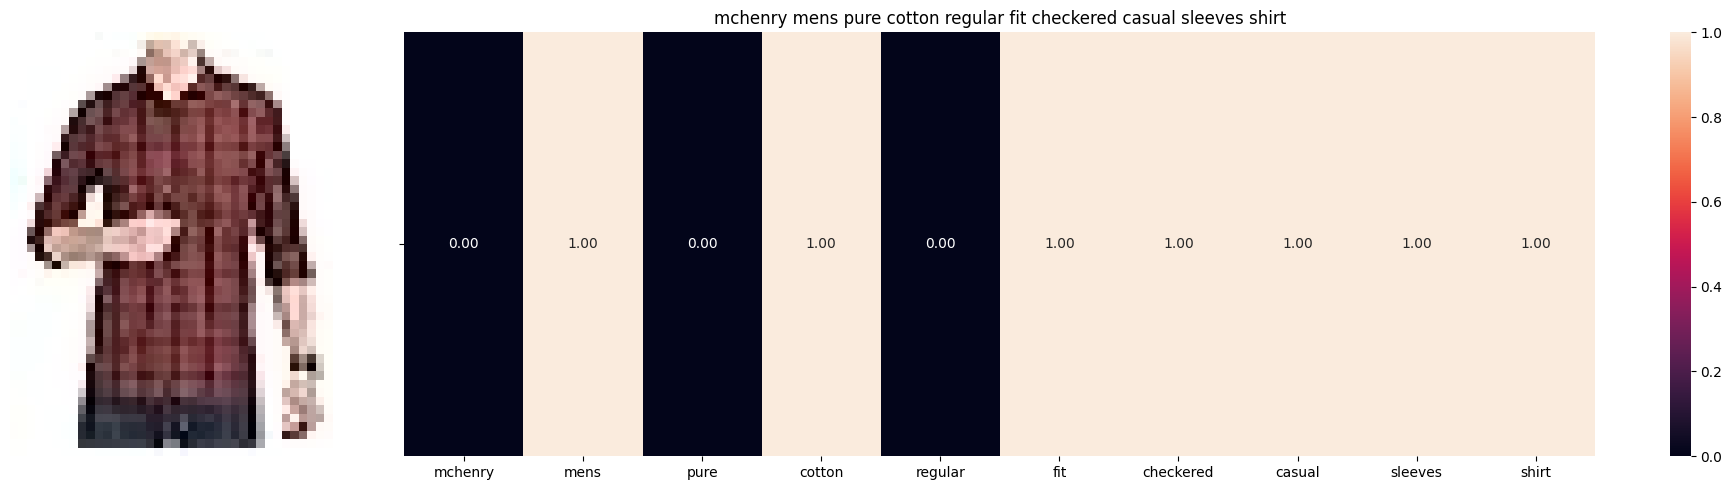

ASIN : B07WVDMWMX
Brand: McHenry
Title: mchenry mens pure cotton regular fit checkered casual sleeves shirt
Euclidean similarity with the query image : 2.449489742783178


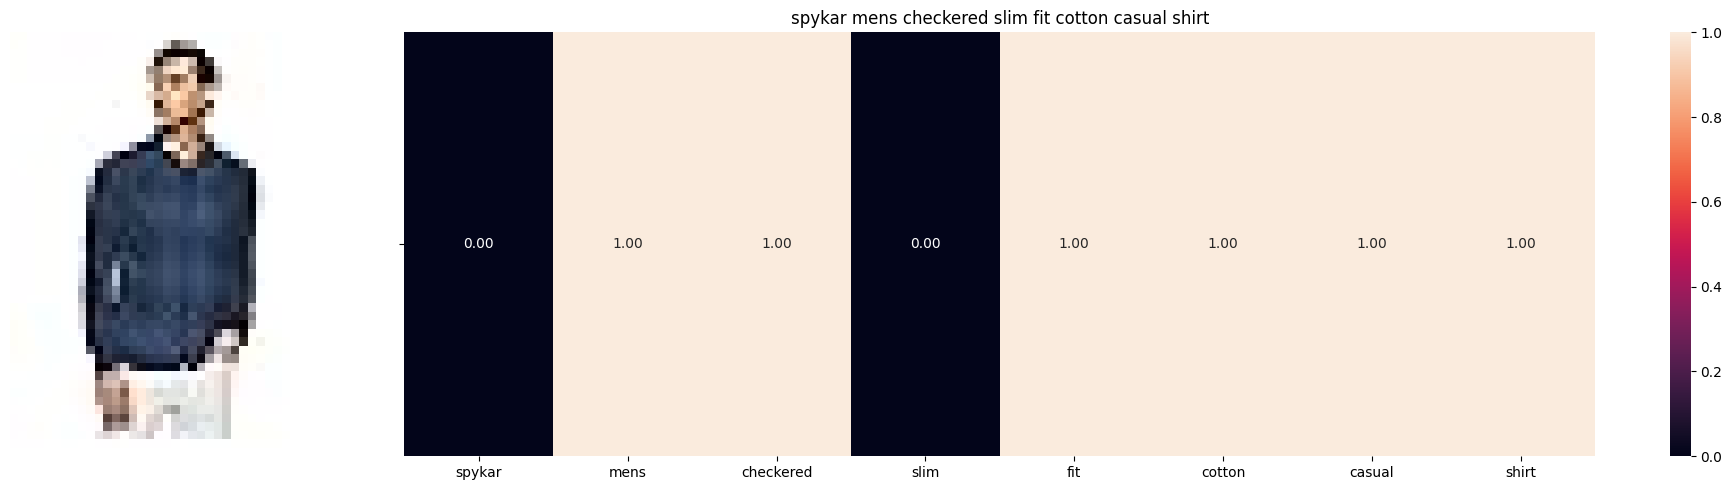

ASIN : B076HK5GLP
Brand: nan
Title: spykar mens checkered slim fit cotton casual shirt
Euclidean similarity with the query image : 2.449489742783178


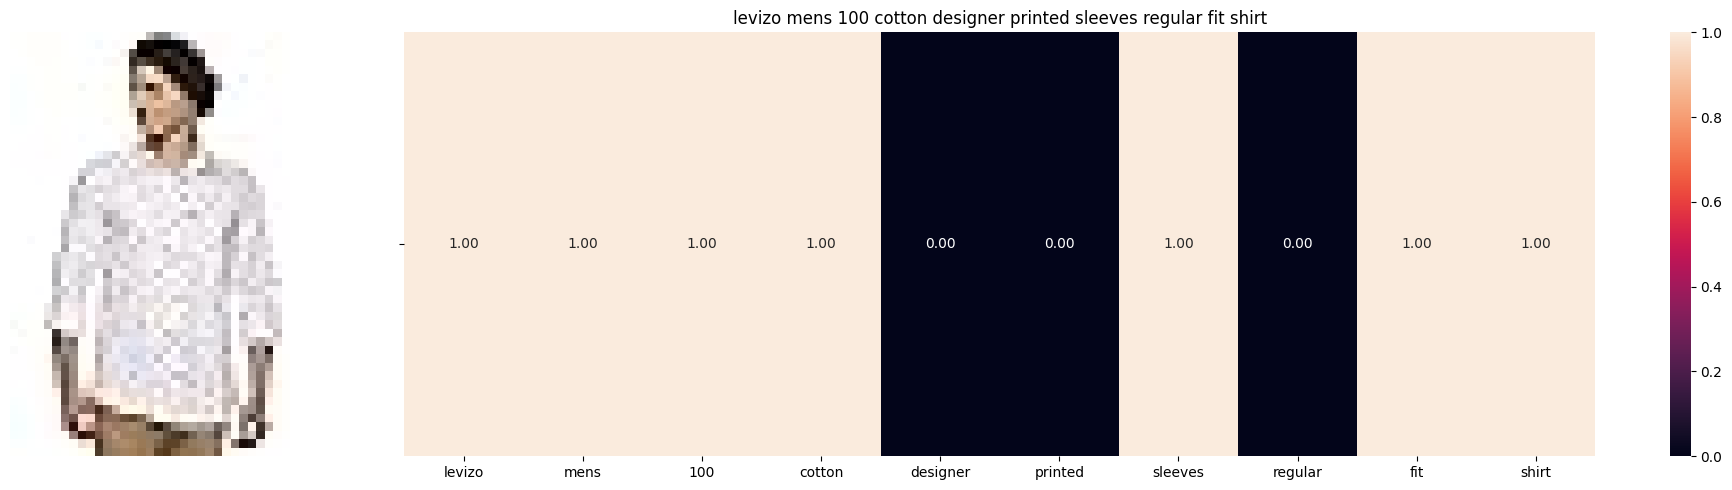

ASIN : B07ZBYTK85
Brand: nan
Title: levizo mens 100 cotton designer printed sleeves regular fit shirt
Euclidean similarity with the query image : 2.449489742783178


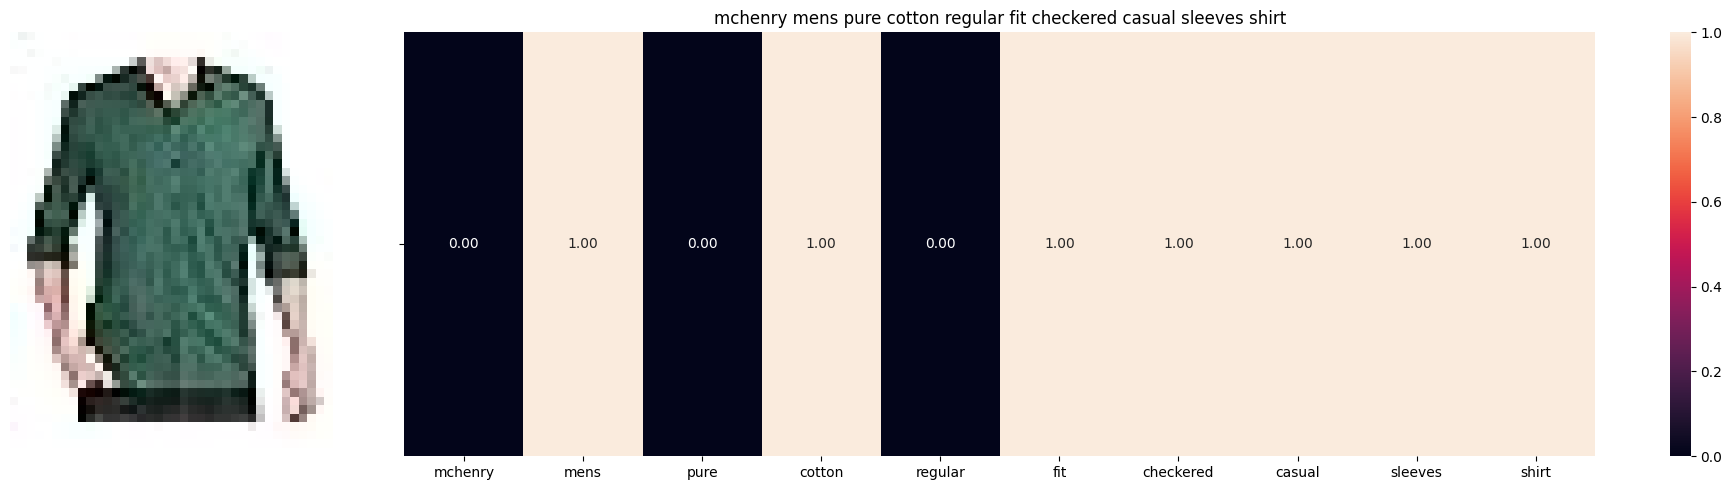

ASIN : B07X5ZQJQS
Brand: McHenry
Title: mchenry mens pure cotton regular fit checkered casual sleeves shirt
Euclidean similarity with the query image : 2.449489742783178


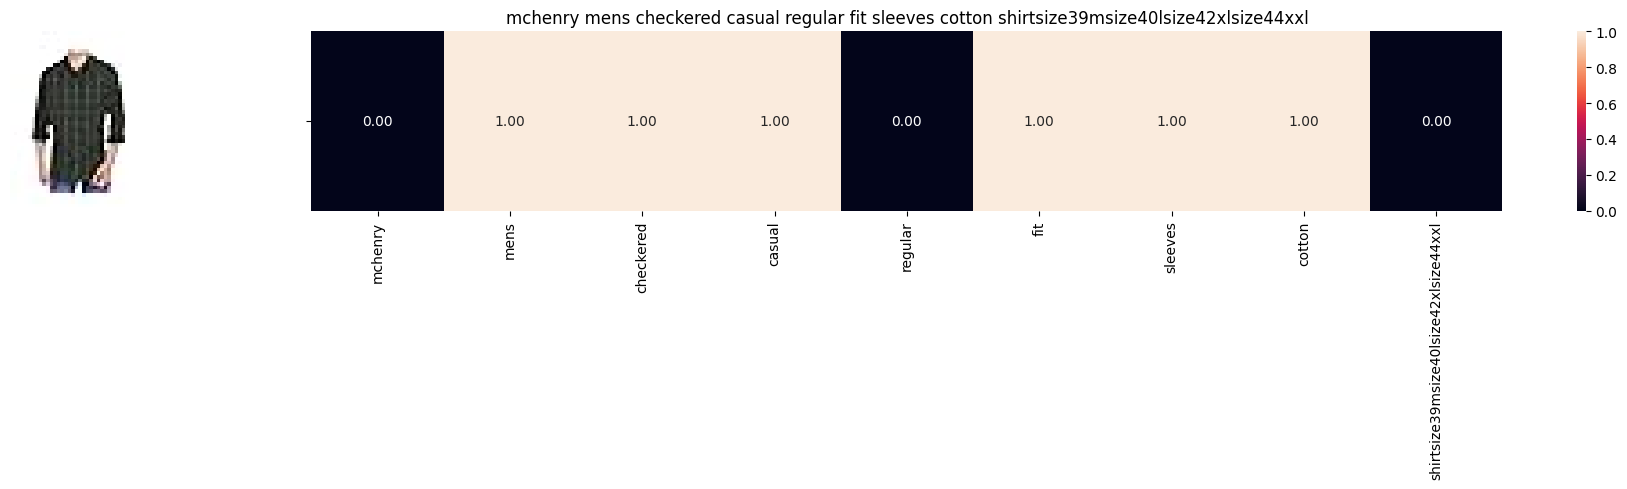

ASIN : B07YMLQ59Z
Brand: McHenry
Title: mchenry mens checkered casual regular fit sleeves cotton shirtsize39msize40lsize42xlsize44xxl
Euclidean similarity with the query image : 2.6457513110645907


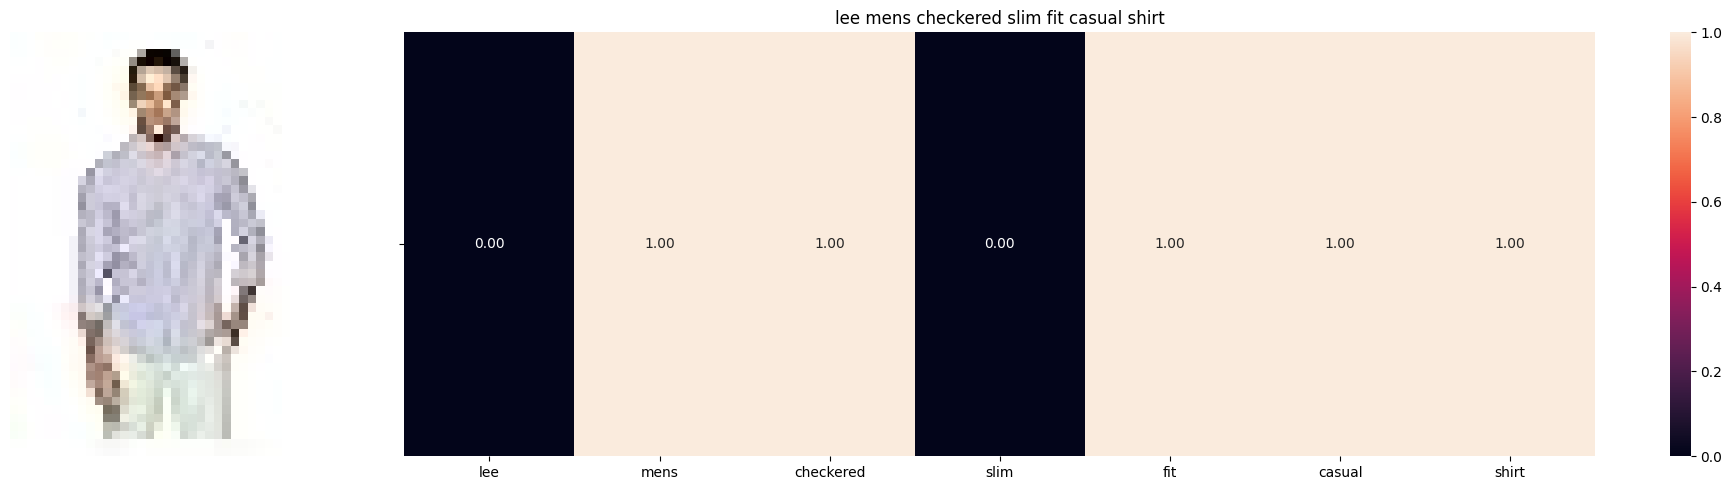

ASIN : B07DMTG5X2
Brand: nan
Title: lee mens checkered slim fit casual shirt
Euclidean similarity with the query image : 2.6457513110645907


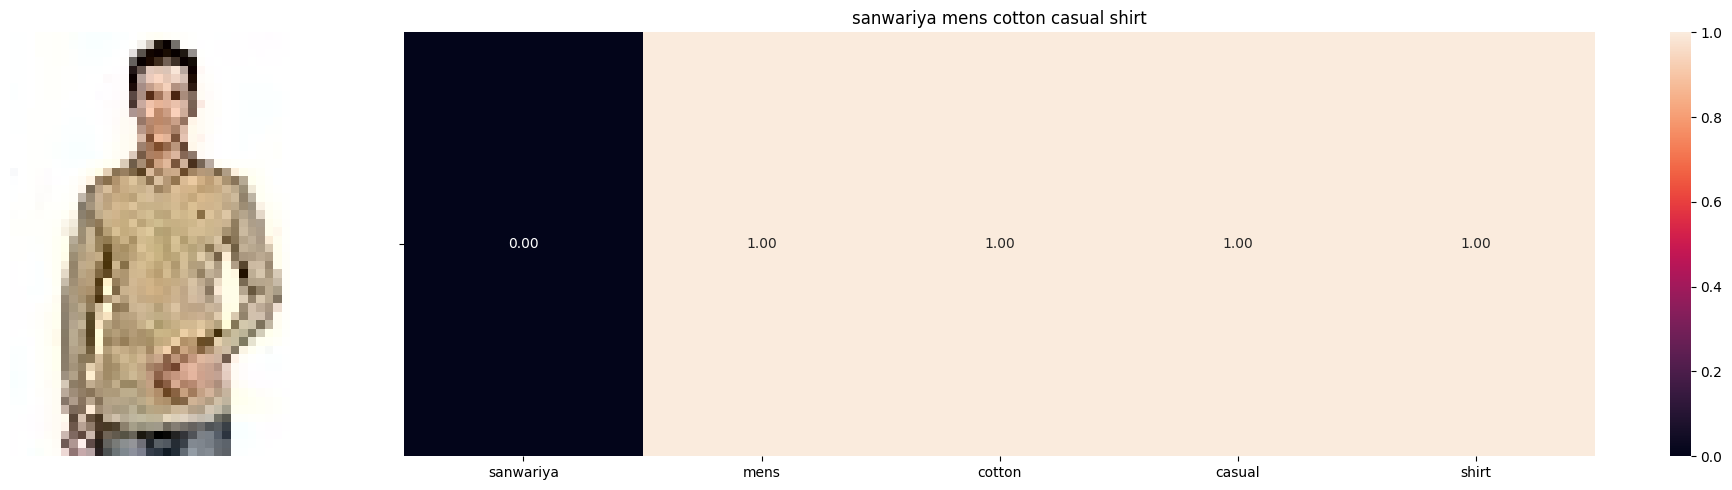

ASIN : B07K5CHLZM
Brand: Sanwariya
Title: sanwariya mens cotton casual shirt
Euclidean similarity with the query image : 2.6457513110645907


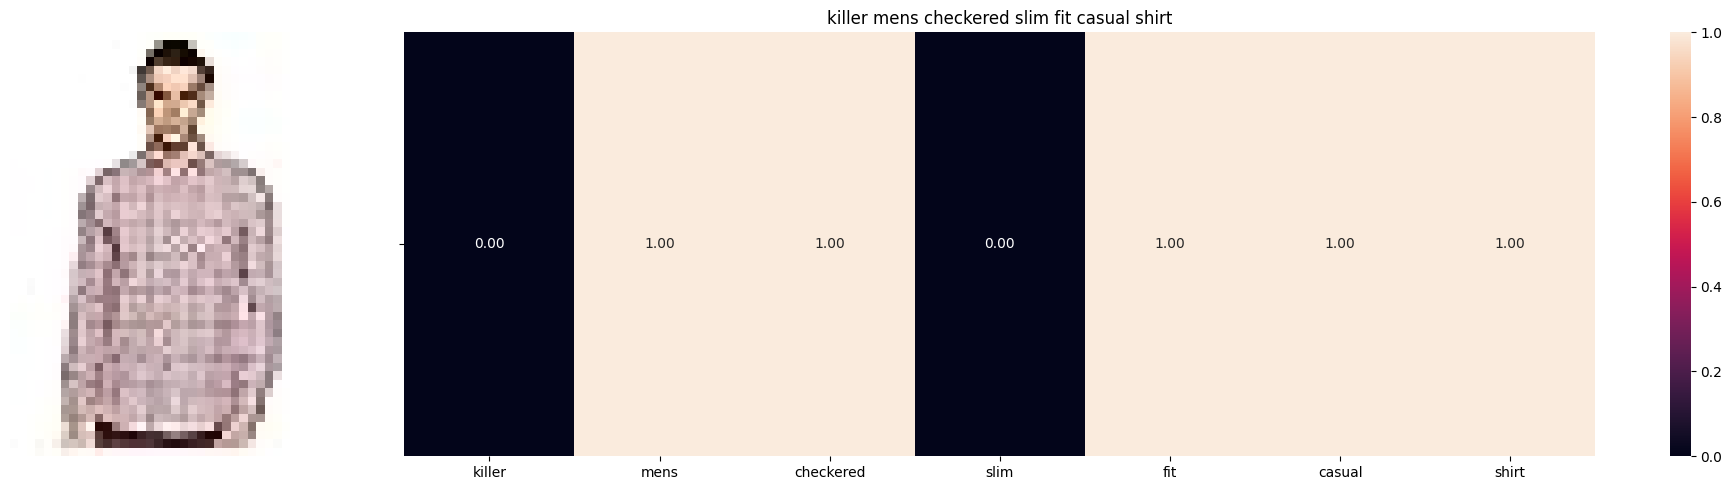

ASIN : B07FHHV6SJ
Brand: nan
Title: killer mens checkered slim fit casual shirt
Euclidean similarity with the query image : 2.6457513110645907


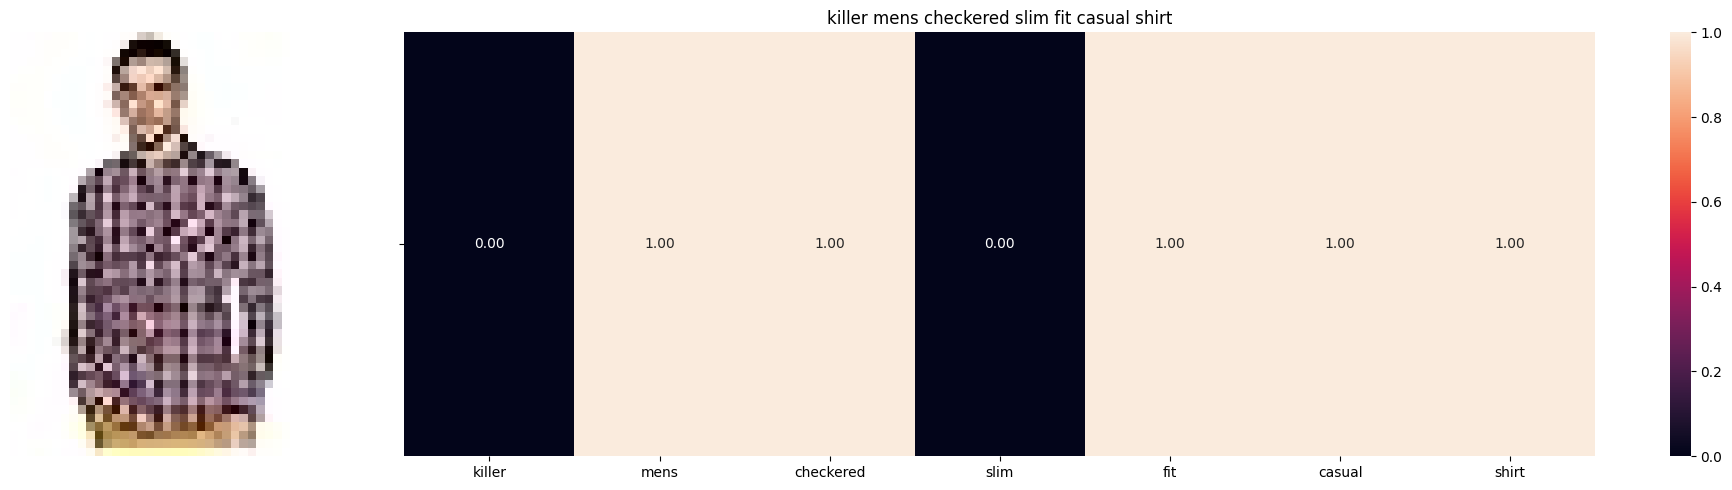

ASIN : B07F39CCTL
Brand: nan
Title: killer mens checkered slim fit casual shirt
Euclidean similarity with the query image : 2.6457513110645907


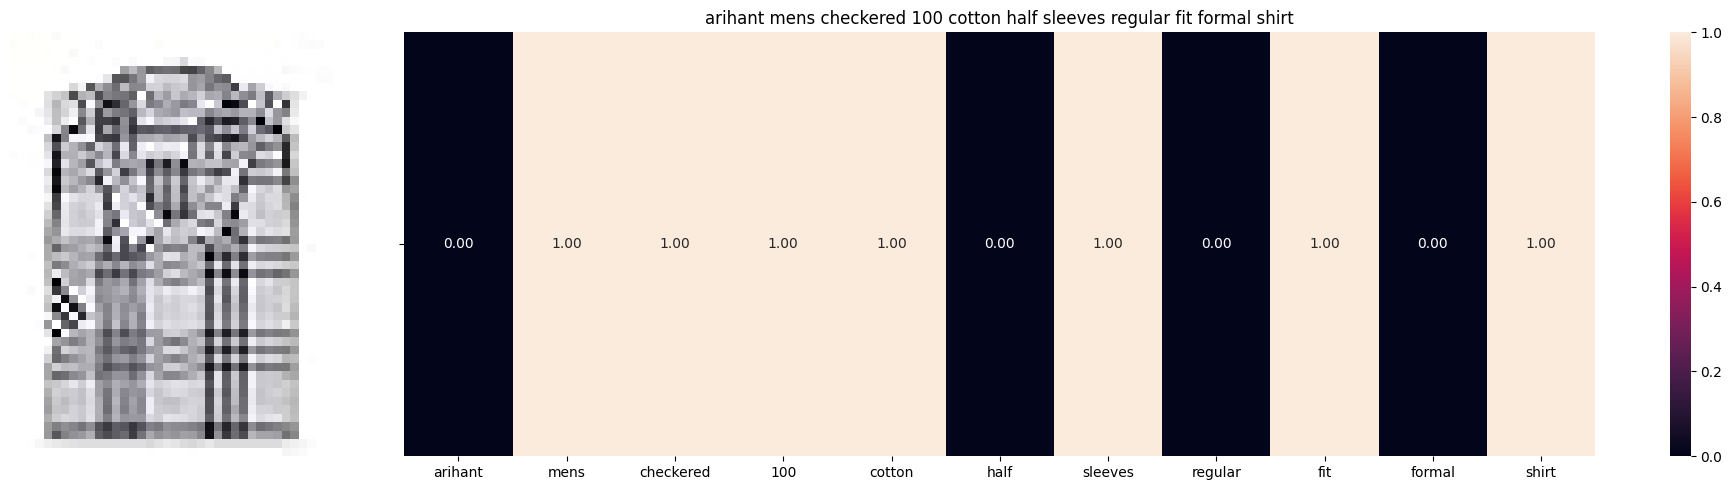

ASIN : B07Q2WSBDR
Brand: Arihant
Title: arihant mens checkered 100 cotton half sleeves regular fit formal shirt
Euclidean similarity with the query image : 2.6457513110645907


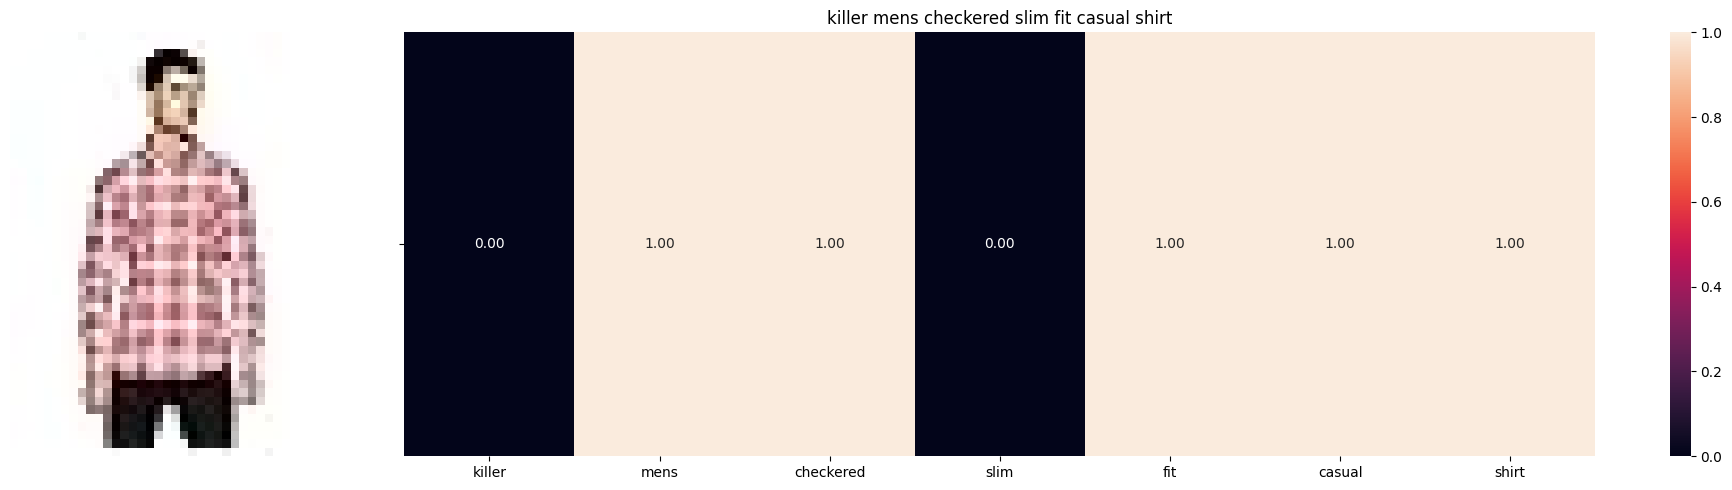

ASIN : B07CTF9S8M
Brand: nan
Title: killer mens checkered slim fit casual shirt
Euclidean similarity with the query image : 2.6457513110645907


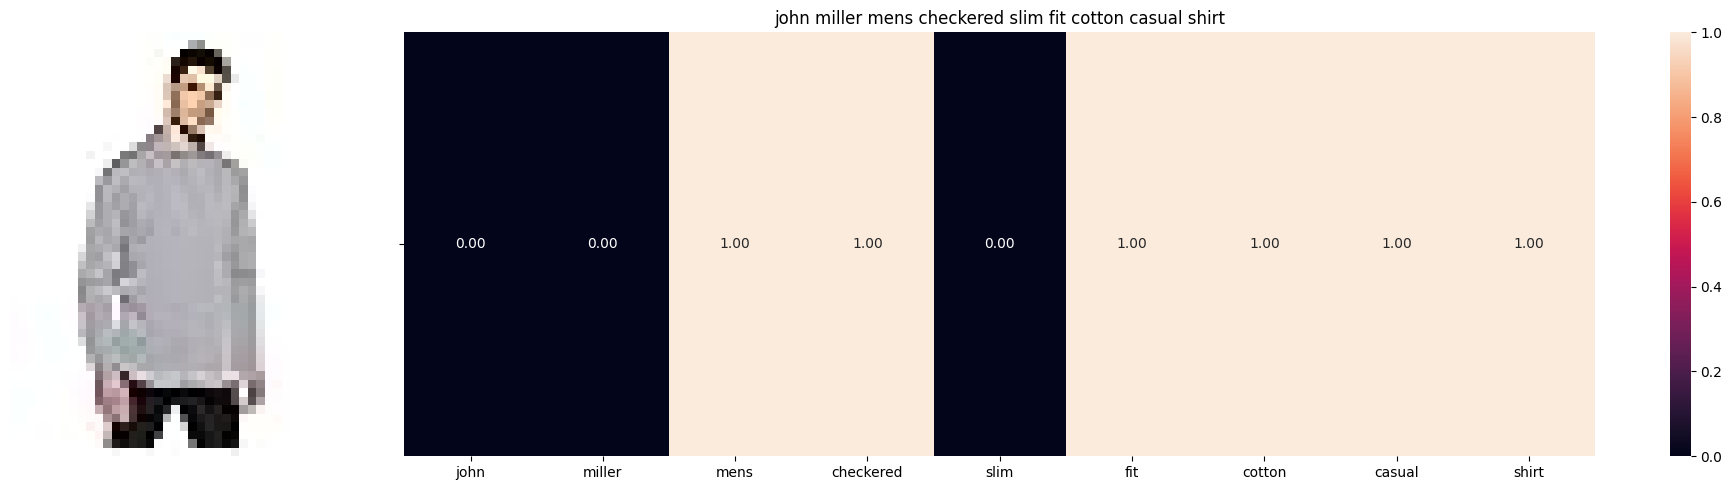

ASIN : B0795VMMDW
Brand: John Miller
Title: john miller mens checkered slim fit cotton casual shirt
Euclidean similarity with the query image : 2.6457513110645907


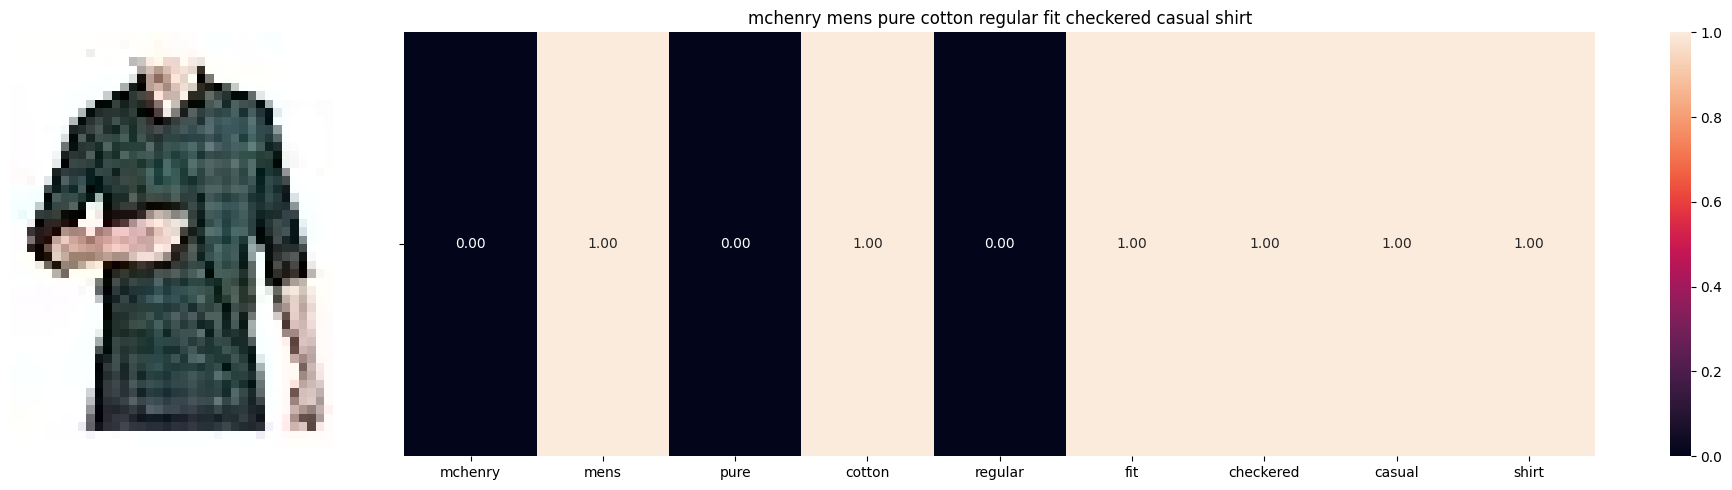

ASIN : B07BJ9NHSM
Brand: McHenry
Title: mchenry mens pure cotton regular fit checkered casual shirt
Euclidean similarity with the query image : 2.6457513110645907


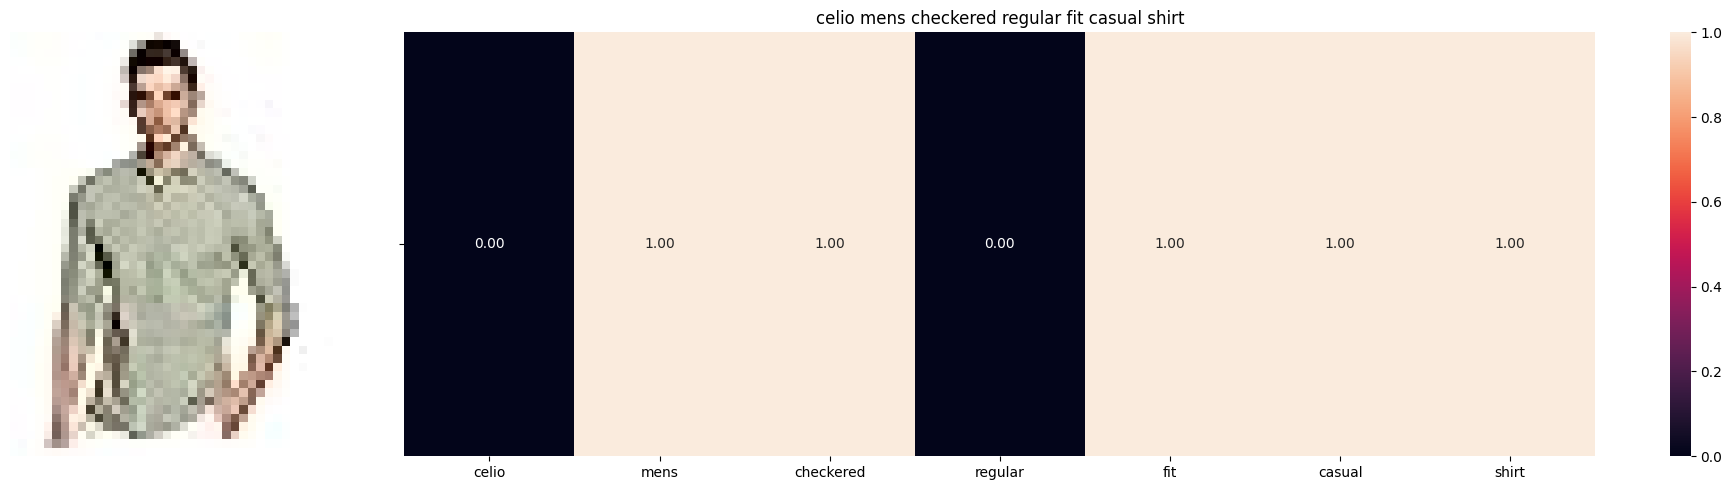

ASIN : B0811Q3XQN
Brand: Celio
Title: celio mens checkered regular fit casual shirt
Euclidean similarity with the query image : 2.6457513110645907


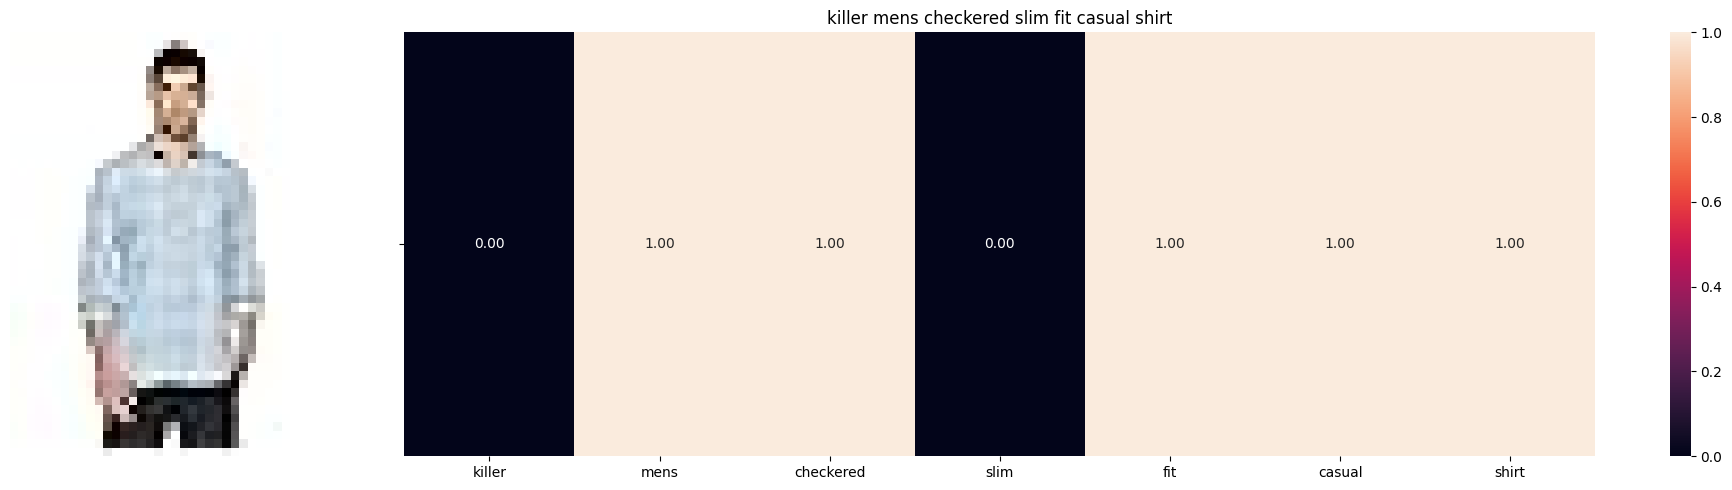

ASIN : B07CTZ2N2J
Brand: nan
Title: killer mens checkered slim fit casual shirt
Euclidean similarity with the query image : 2.6457513110645907


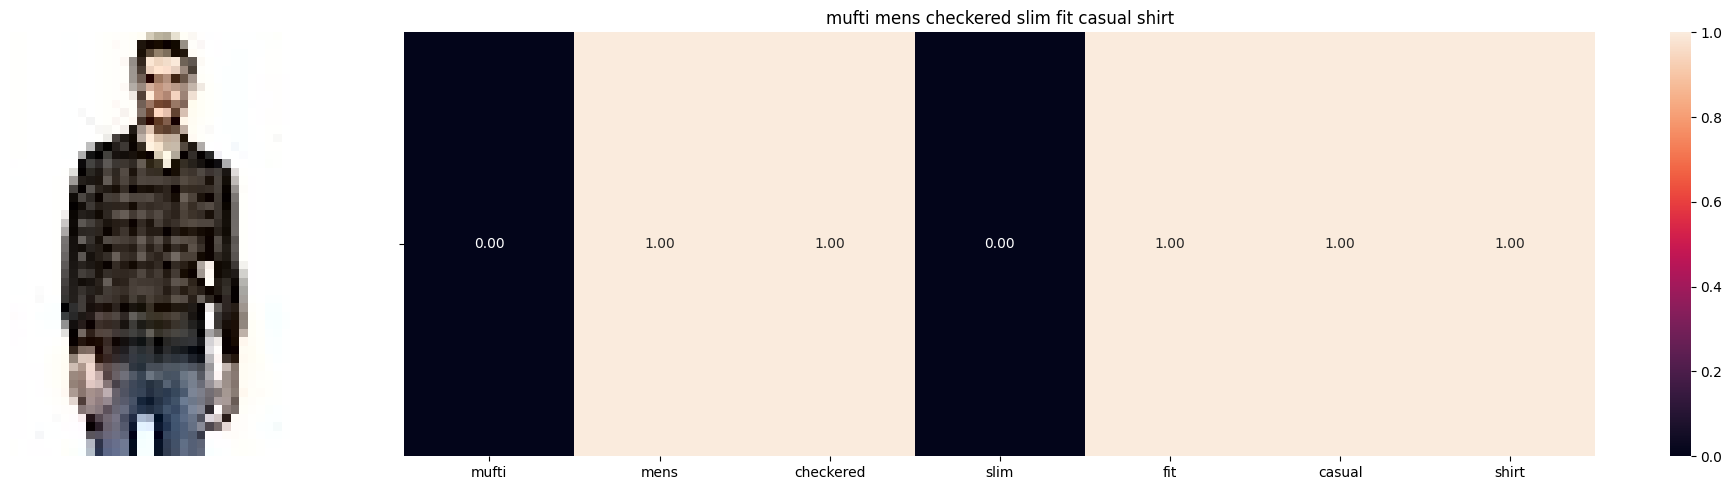

ASIN : B07FPTP1DN
Brand: Mufti
Title: mufti mens checkered slim fit casual shirt
Euclidean similarity with the query image : 2.6457513110645907


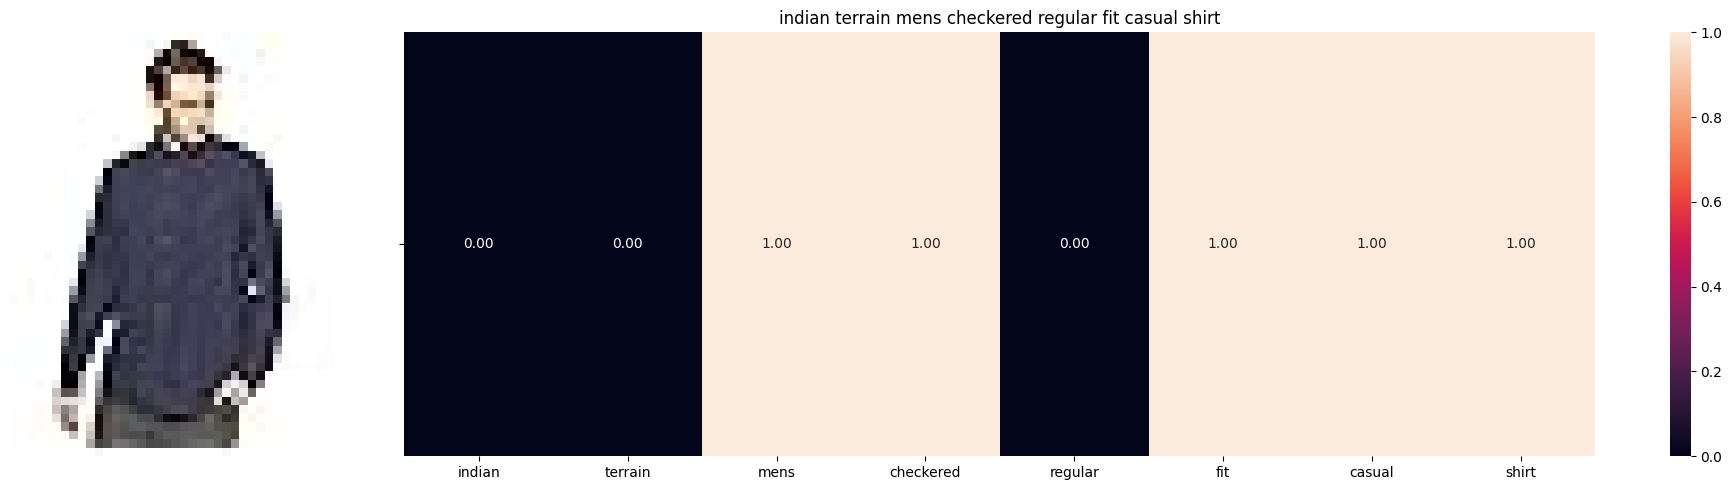

ASIN : B07FZF8Z5G
Brand: Indian Terrain
Title: indian terrain mens checkered regular fit casual shirt
Euclidean similarity with the query image : 2.8284271247461903


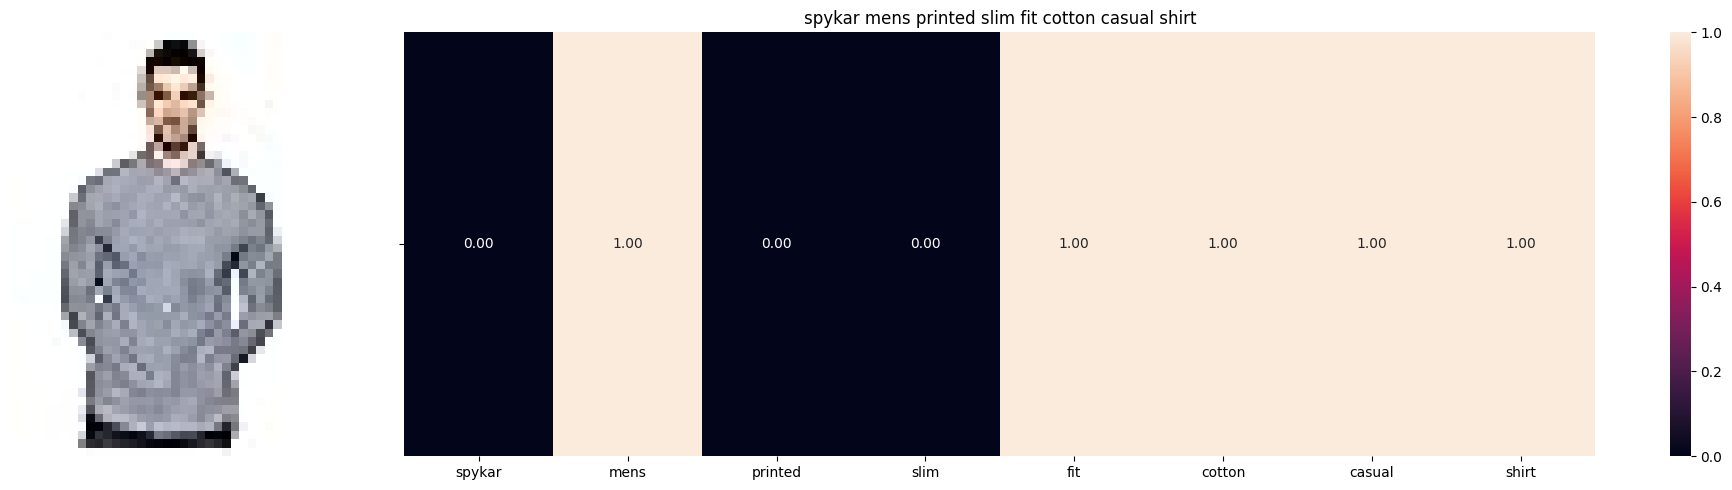

ASIN : B076BQQC39
Brand: nan
Title: spykar mens printed slim fit cotton casual shirt
Euclidean similarity with the query image : 2.8284271247461903


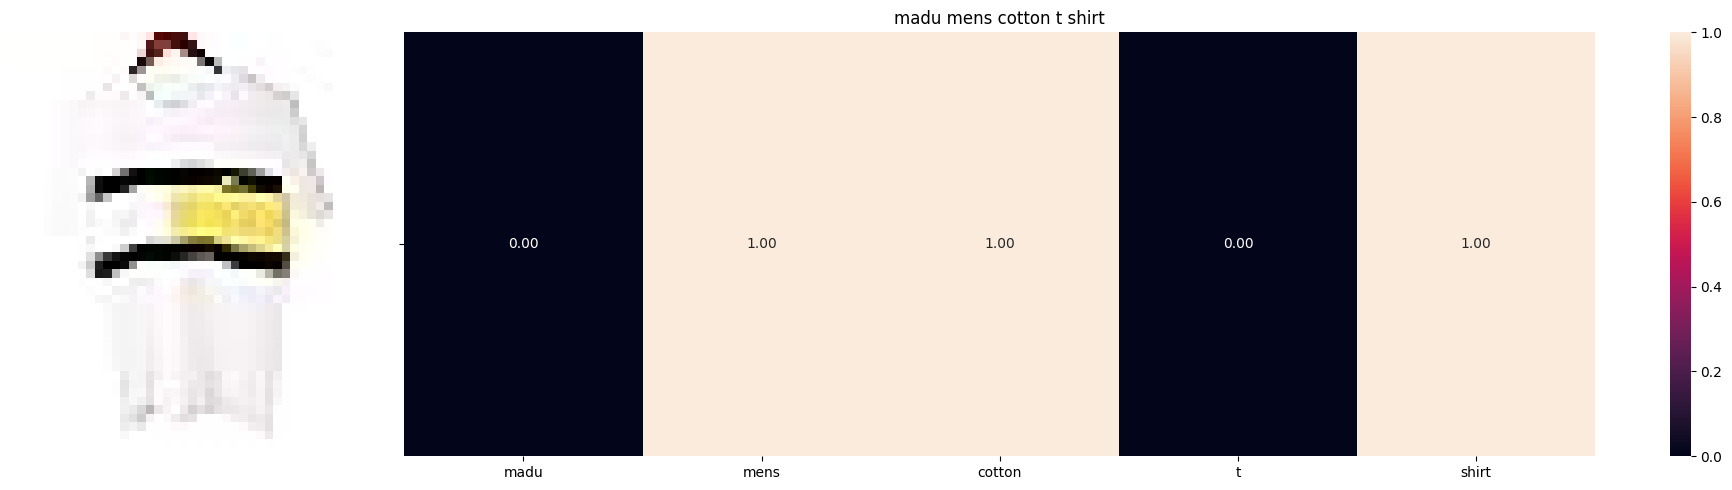

ASIN : B07Z444BV8
Brand: MAD'U'
Title: madu mens cotton t shirt
Euclidean similarity with the query image : 2.8284271247461903


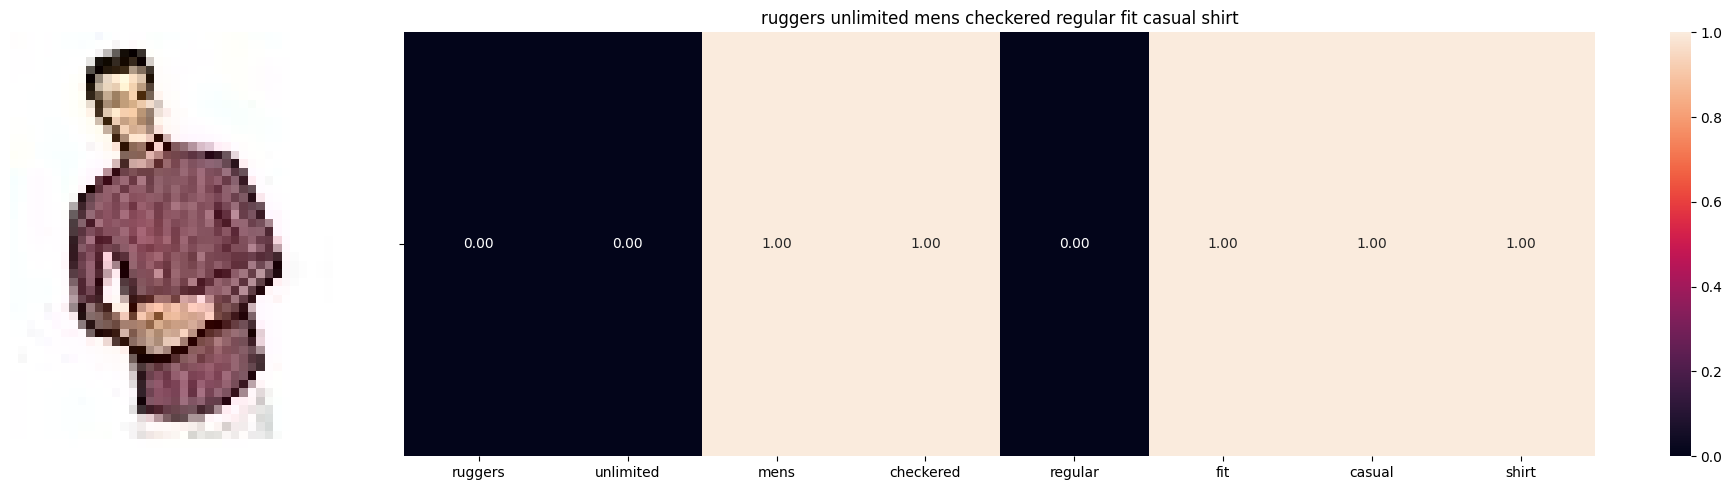

ASIN : B07DYRV13L
Brand: nan
Title: ruggers unlimited mens checkered regular fit casual shirt
Euclidean similarity with the query image : 2.8284271247461903


In [47]:
def bag_of_words_model(doc_id, num_results):
    if doc_id >= title_features.shape[0]:
        print("Invalid doc_id. Max index:", (title_features.shape[0]) - 1)
        return
    
    pairwise_dist = pairwise_distances(title_features, title_features[doc_id].reshape(1,-1)).reshape(-1)
                                                                                                    
    indices = np.argsort(pairwise_dist)

    # remove self-match
    indices = indices[indices != doc_id]

    # top results
    indices = indices[:num_results]
    pdists = pairwise_dist[indices]
    #indices = np.argsort(pairwise_dist.flatten())[0:num_results]
    
    #pdists = np.sort(pairwise_dist.flatten())[0:num_results]
    
    df_indices = list(data.index[indices])
    query_title = data['product_name'].iloc[doc_id]
    for i in range(0,len(indices)):
        idx = indices[i]
        image_url = None
        val = data['image_urls__small'].iloc[idx]
        if isinstance(val, str):
            image_url = val.split()[0]

        get_result(
            idx,
            query_title,
            data['product_name'].iloc[idx],
            image_url,
            'bag_of_words'
        )
        # we will pass 1. doc_id, 2. title1, 3. title2, url, model
        #get_result(indices[i],data['product_name'].loc[df_indices[0]], data['product_name'].loc[df_indices[i]], data['image_urls__small'].loc[df_indices[i]], 'bag_of_words')
        print('ASIN :',data['asin'].iloc[idx])
        print ('Brand:', data['brand'].iloc[idx])
        print ('Title:', data['product_name'].iloc[idx])
        print ('Euclidean similarity with the query image :', pdists[i])
        print('='*60)

        
        
bag_of_words_model(5570, 20)

In [48]:
print(title_features.shape)
print(data.shape)

(5697, 5583)
(5697, 33)


In [49]:
print(data.columns)

Index(['uniq_id', 'crawl_timestamp', 'asin', 'product_url', 'product_name',
       'image_urls__small', 'medium', 'large', 'browsenode', 'brand',
       'sales_price', 'weight', 'rating', 'sales_rank_in_parent_category',
       'sales_rank_in_child_category', 'delivery_type', 'meta_keywords',
       'amazon_prime__y_or_n', 'parent___child_category__all',
       'best_seller_tag__y_or_n', 'other_items_customers_buy',
       'product_details__k_v_pairs', 'discount_percentage', 'colour',
       'no__of_reviews', 'seller_name', 'seller_id', 'left_in_stock',
       'no__of_offers', 'no__of_sellers', 'technical_details__k_v_pairs',
       'formats___editions', 'name_of_author_for_books'],
      dtype='str')


In [50]:
# by using the tfidf based product similarity
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_title_vectorizer = TfidfVectorizer()
tfidf_title_features = tfidf_title_vectorizer.fit_transform(data['product_name'])

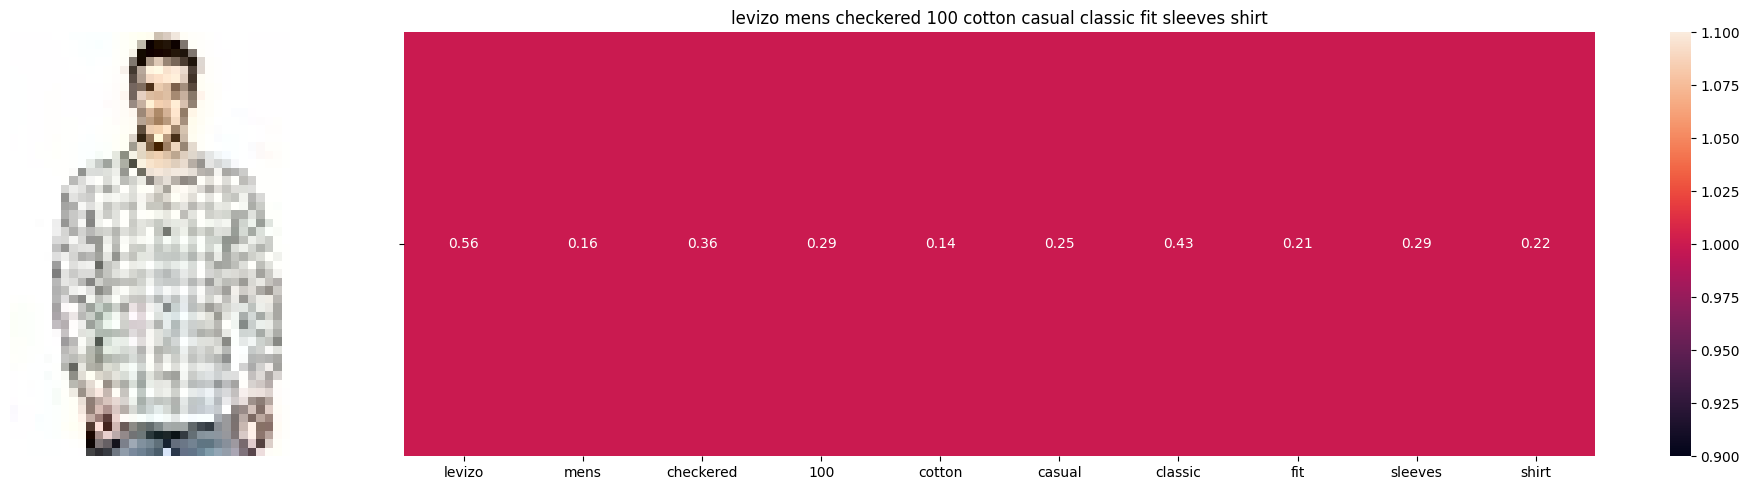

ASIN : B07ZBX33MN
BRAND : nan
Eucliden distance from the given image : 0.0


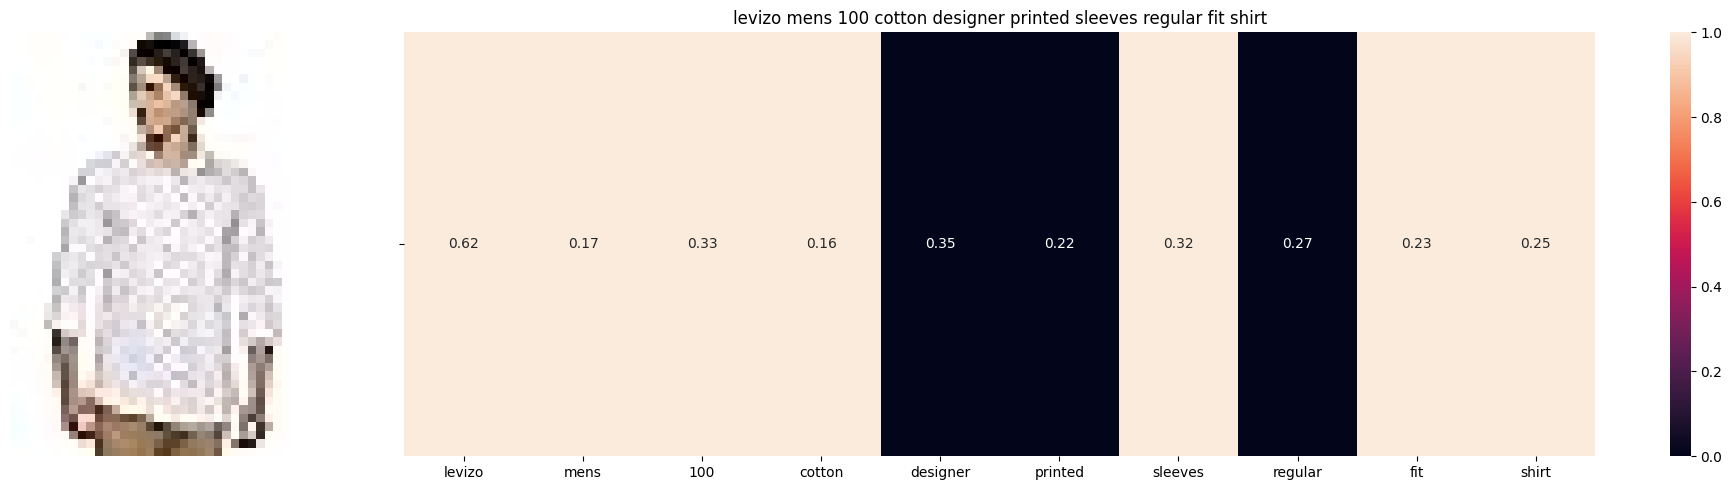

ASIN : B07ZBYTK85
BRAND : nan
Eucliden distance from the given image : 0.7941901648646585
No common words → skipping heatmap
ASIN : B083X4QH2Y
BRAND : nan
Eucliden distance from the given image : 1.0


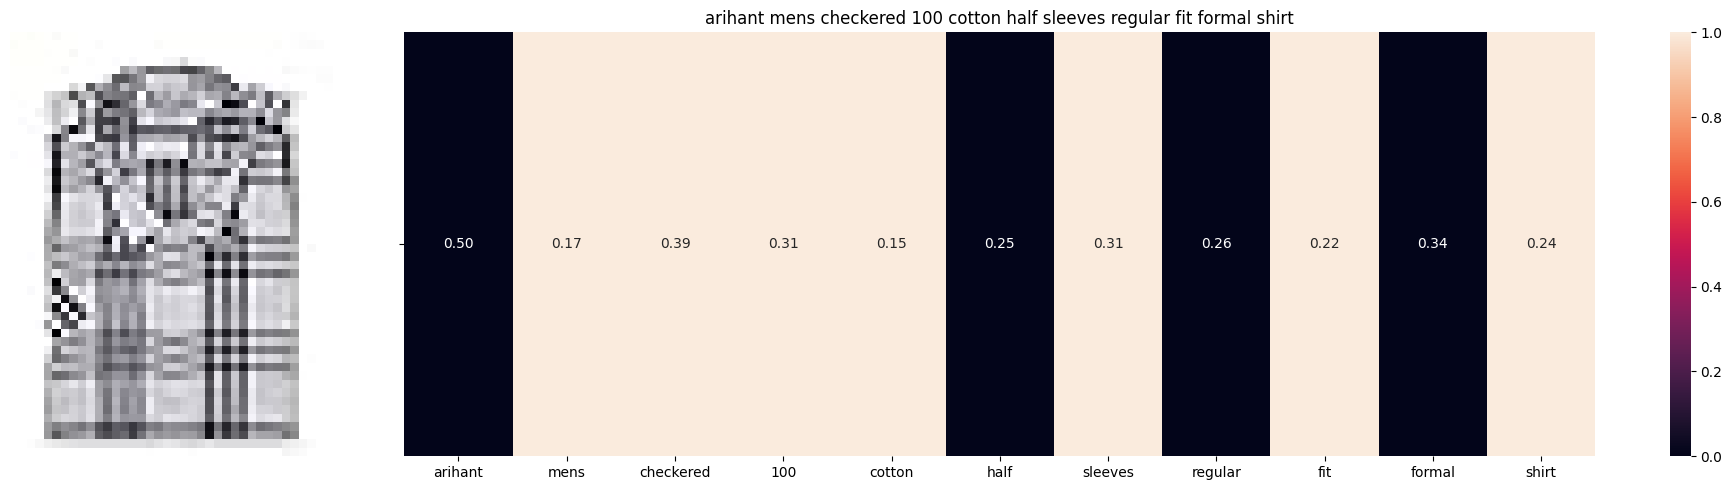

ASIN : B07Q2WSBDR
BRAND : Arihant
Eucliden distance from the given image : 1.0329416315987747


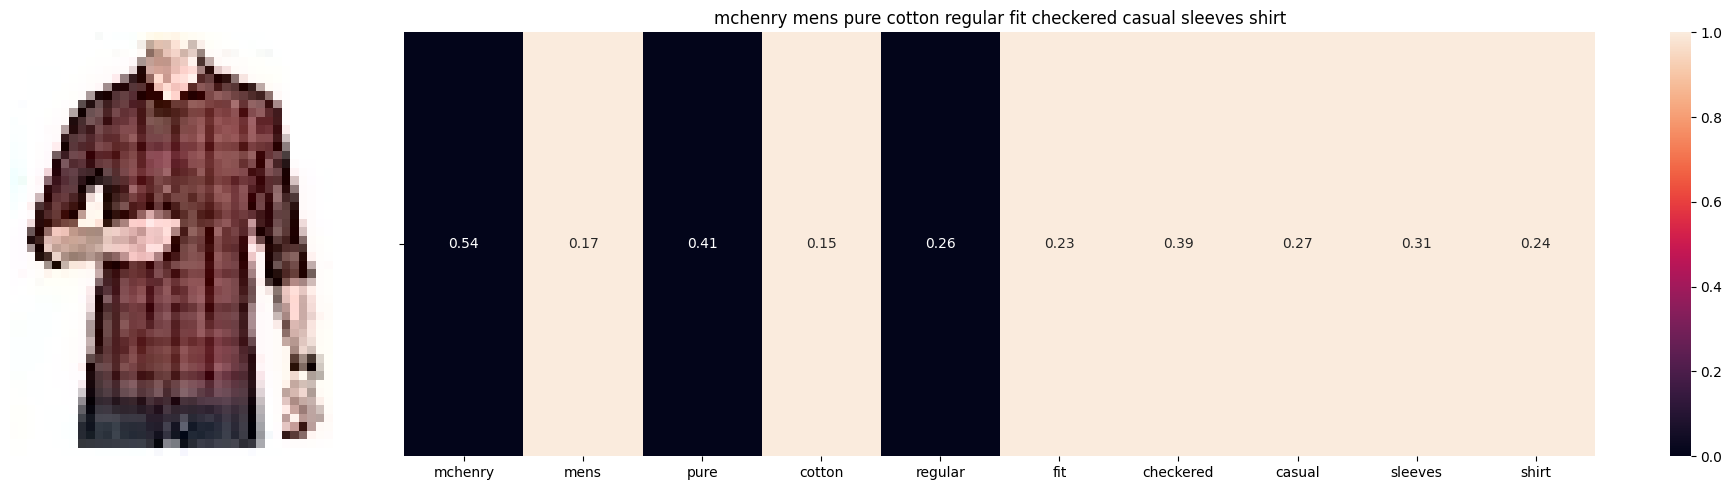

ASIN : B07WVDMWMX
BRAND : McHenry
Eucliden distance from the given image : 1.053699366507793


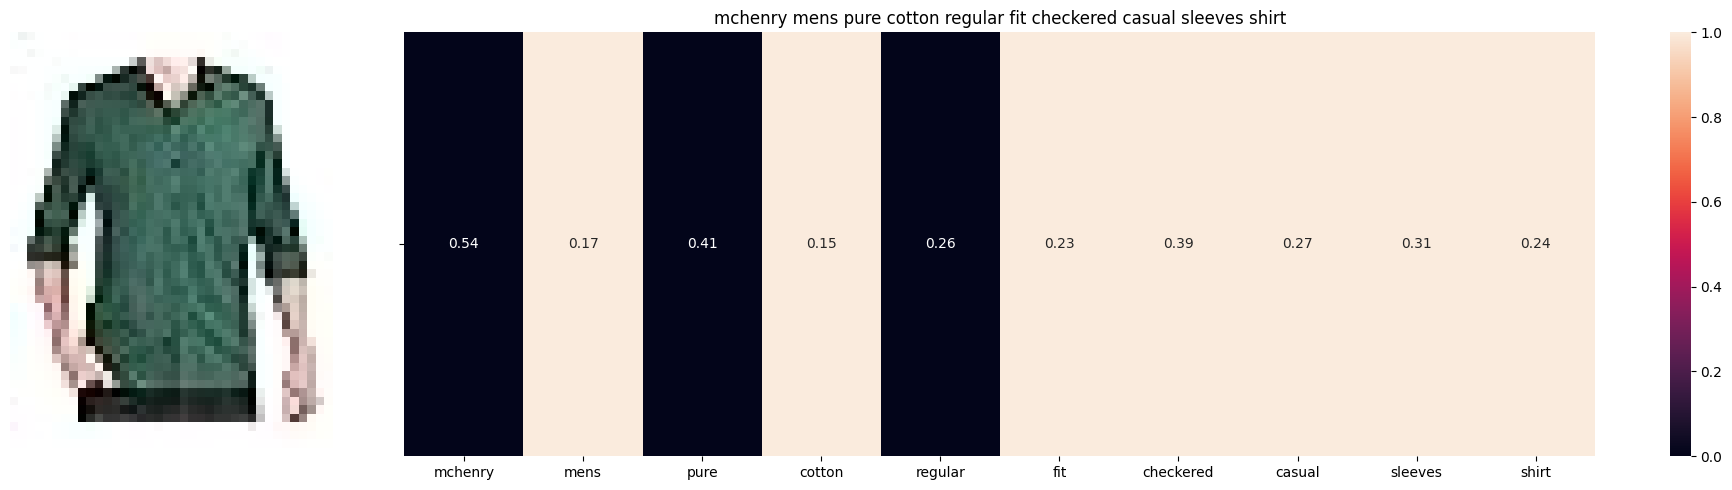

ASIN : B07X5ZQJQS
BRAND : McHenry
Eucliden distance from the given image : 1.053699366507793


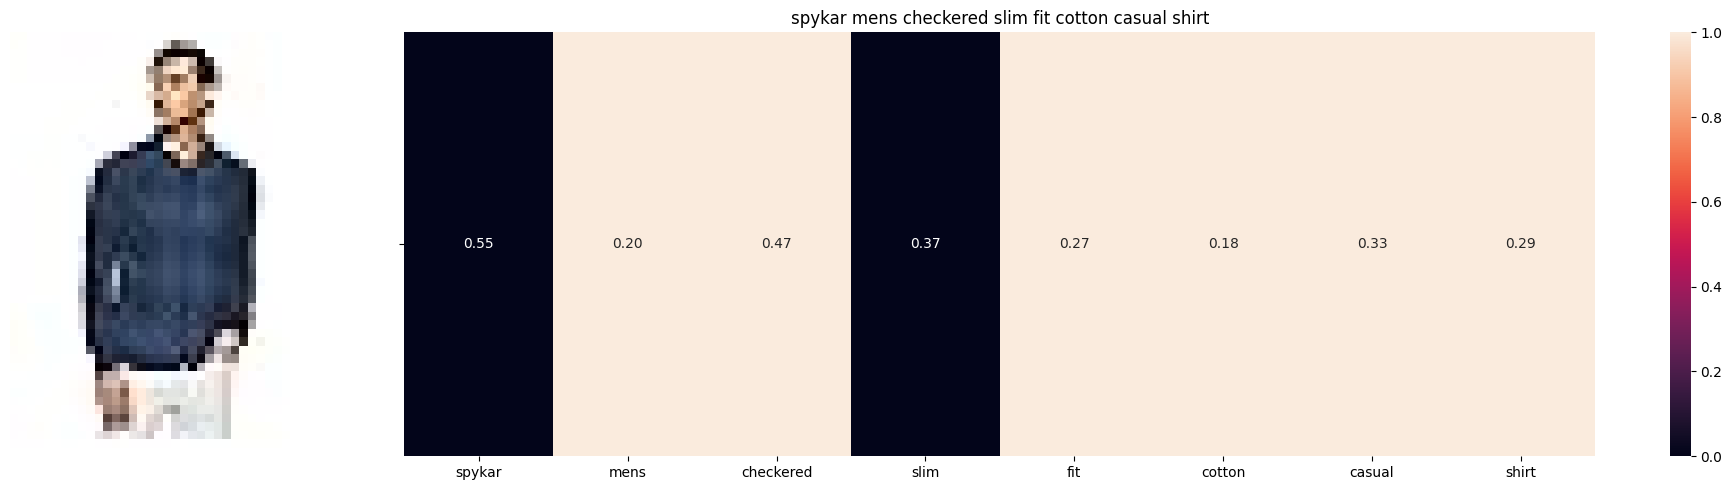

ASIN : B076HK5GLP
BRAND : nan
Eucliden distance from the given image : 1.0683427872635907


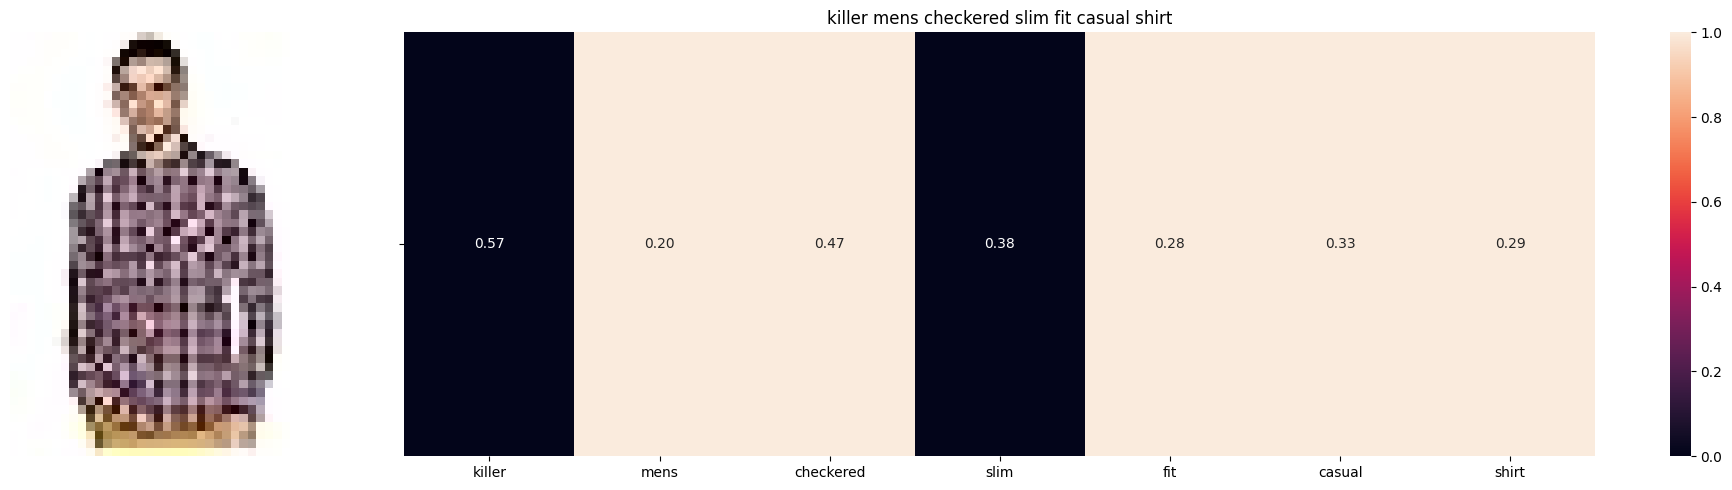

ASIN : B07F39CCTL
BRAND : nan
Eucliden distance from the given image : 1.0871204132322838


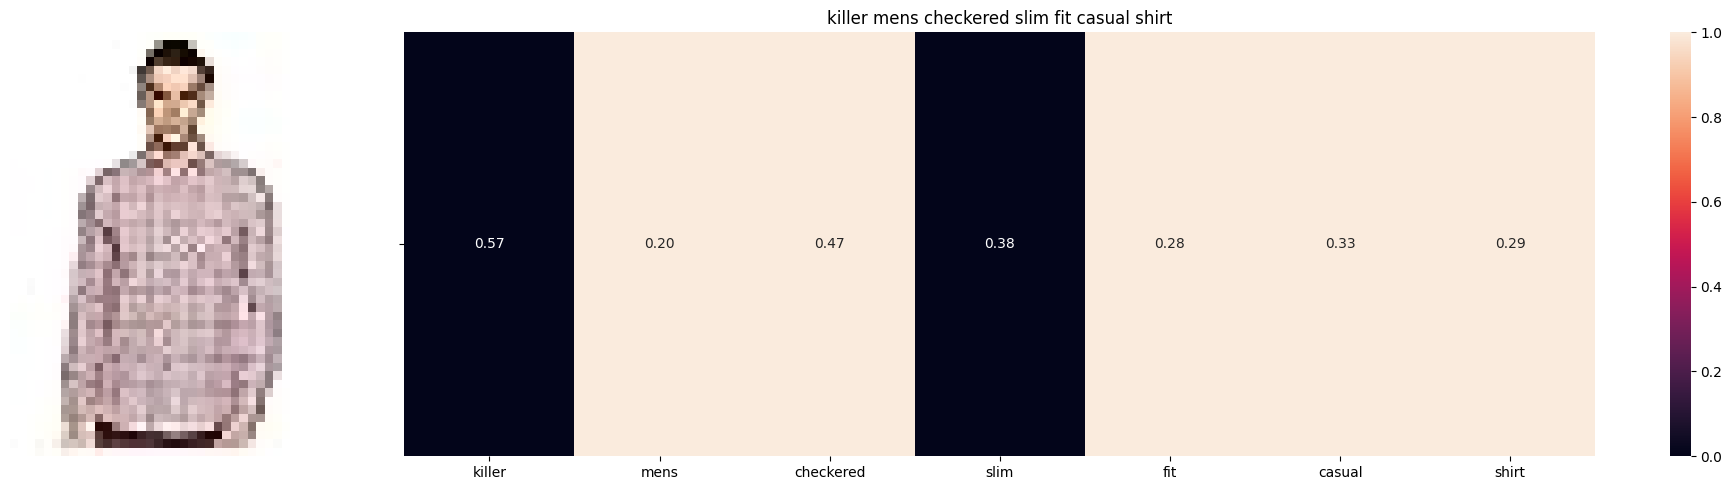

ASIN : B07FHHV6SJ
BRAND : nan
Eucliden distance from the given image : 1.0871204132322838


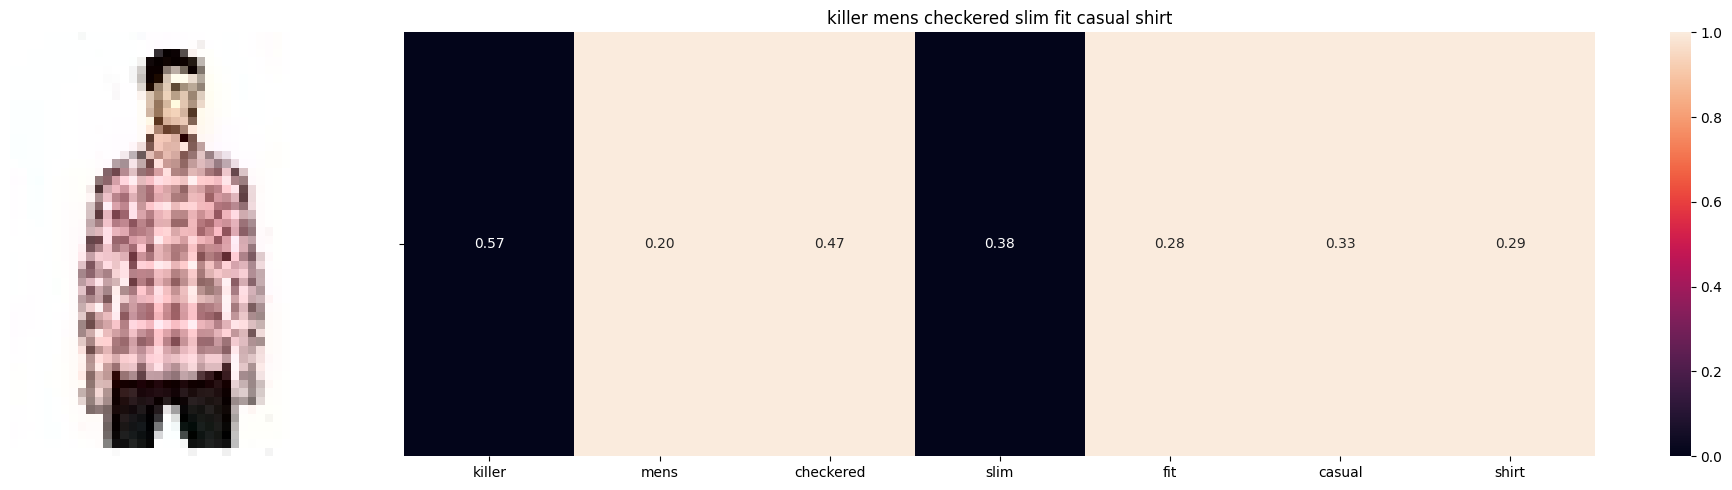

ASIN : B07CTF9S8M
BRAND : nan
Eucliden distance from the given image : 1.0871204132322838


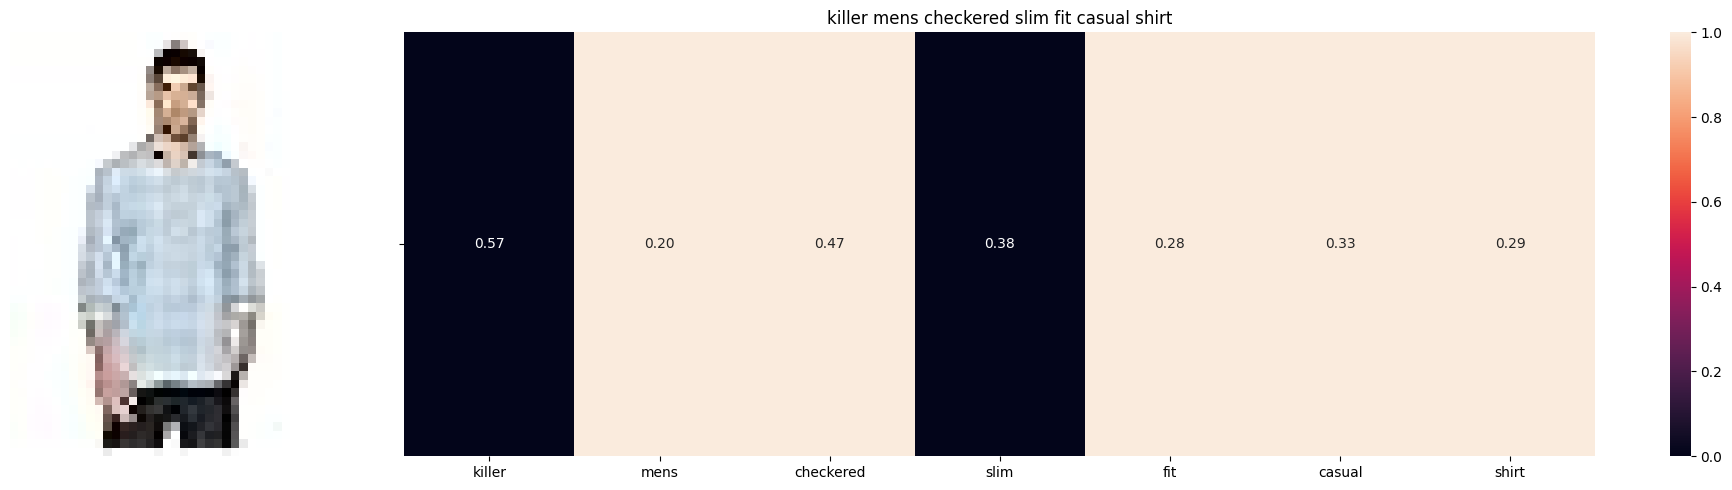

ASIN : B07CTZ2N2J
BRAND : nan
Eucliden distance from the given image : 1.0871204132322838


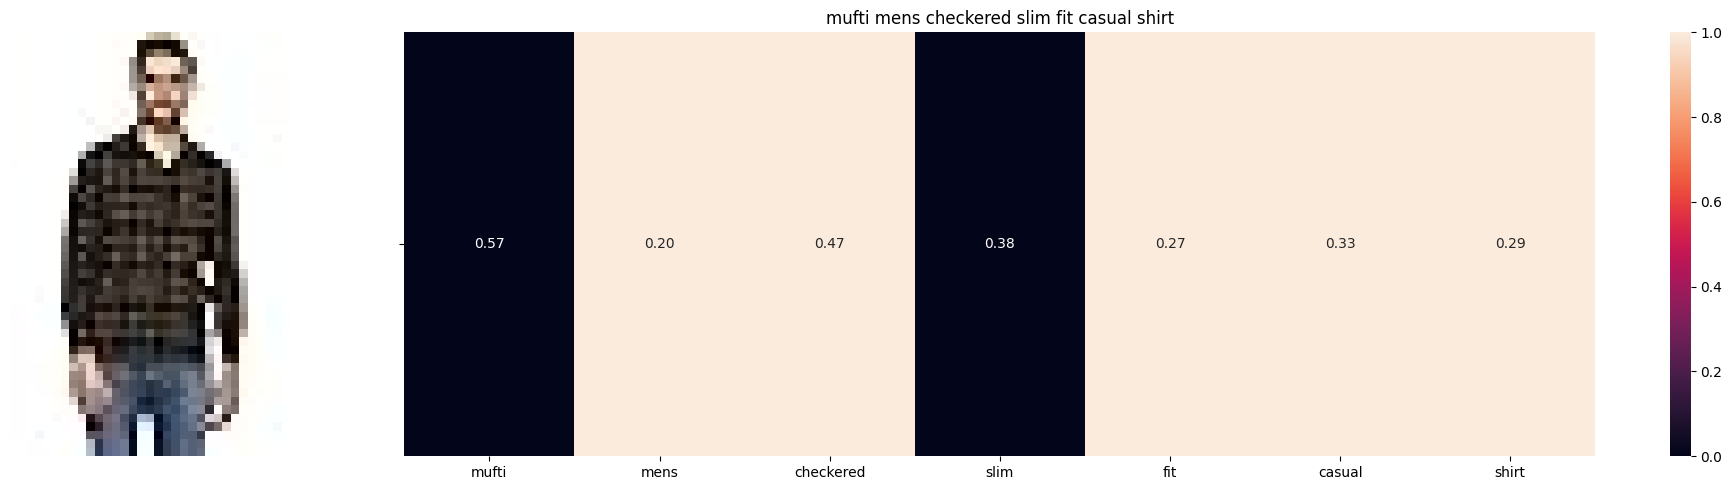

ASIN : B07FPTP1DN
BRAND : Mufti
Eucliden distance from the given image : 1.089521908717596


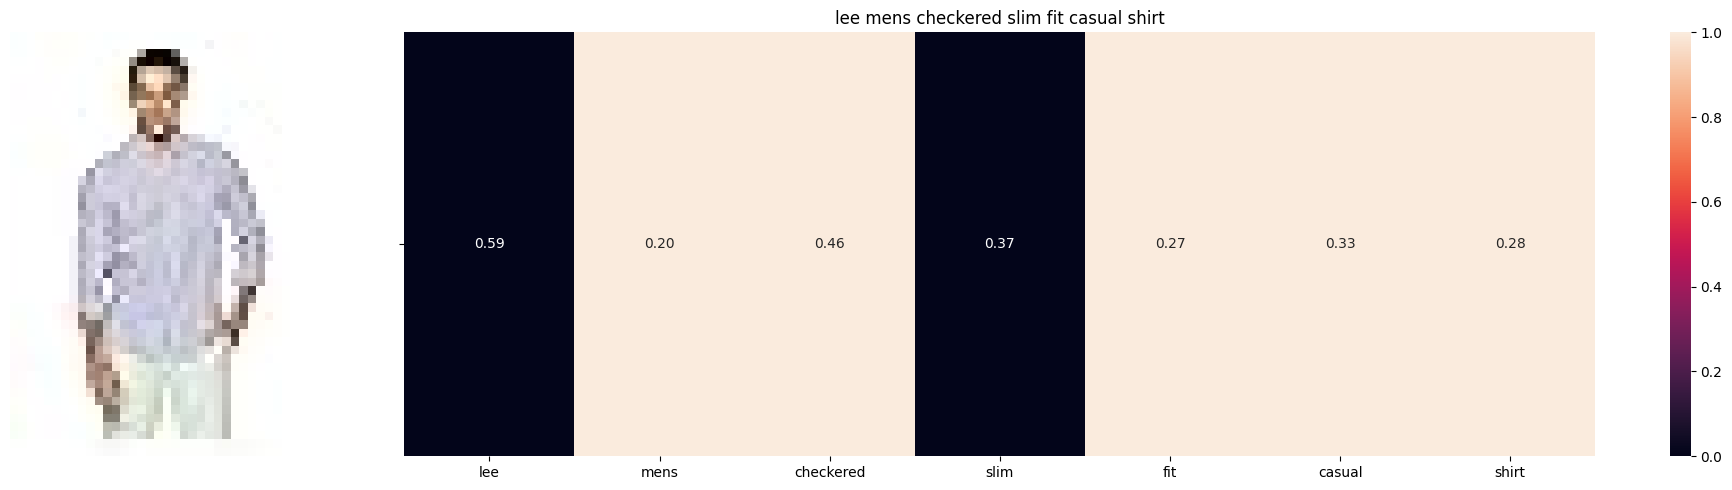

ASIN : B07DMTG5X2
BRAND : nan
Eucliden distance from the given image : 1.0932816257850448


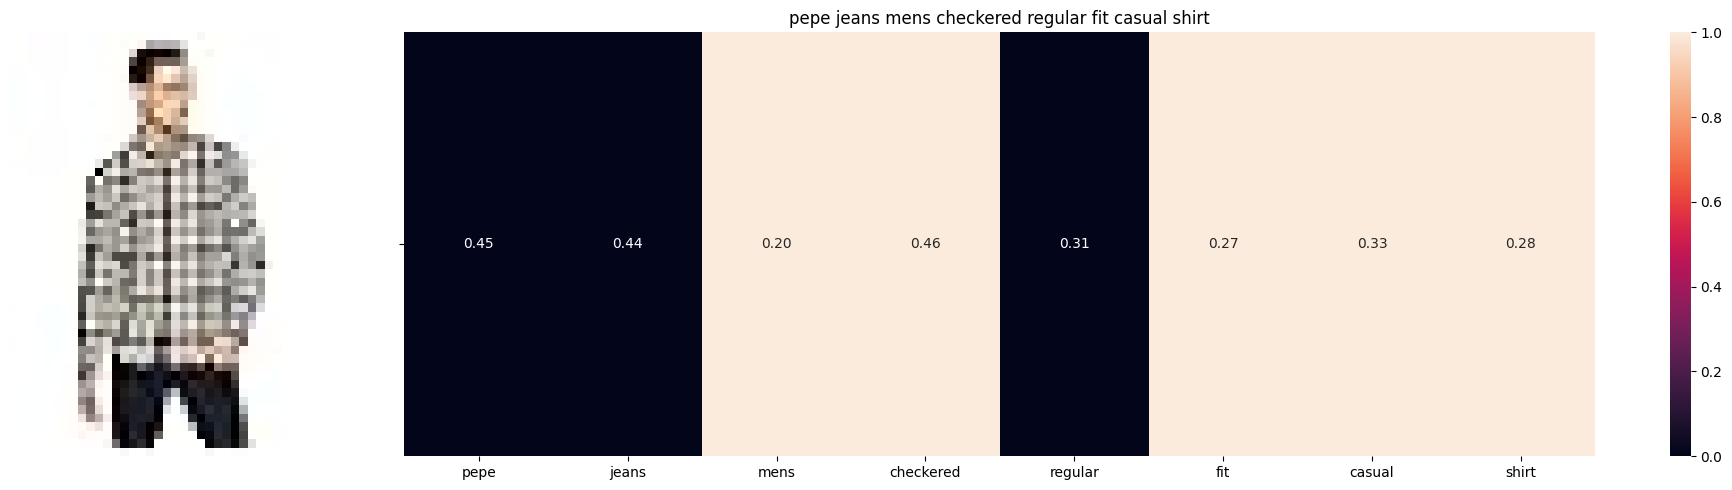

ASIN : B07FKM7TMZ
BRAND : nan
Eucliden distance from the given image : 1.094817578970771


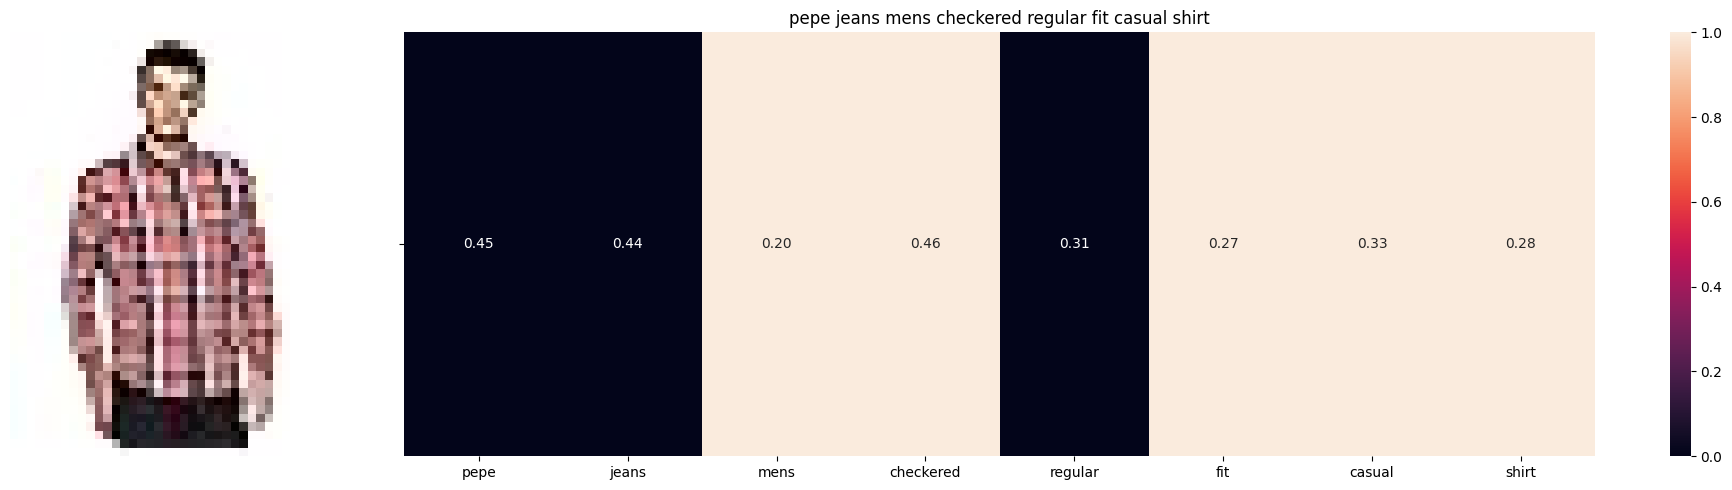

ASIN : B07FKM8T7S
BRAND : nan
Eucliden distance from the given image : 1.094817578970771


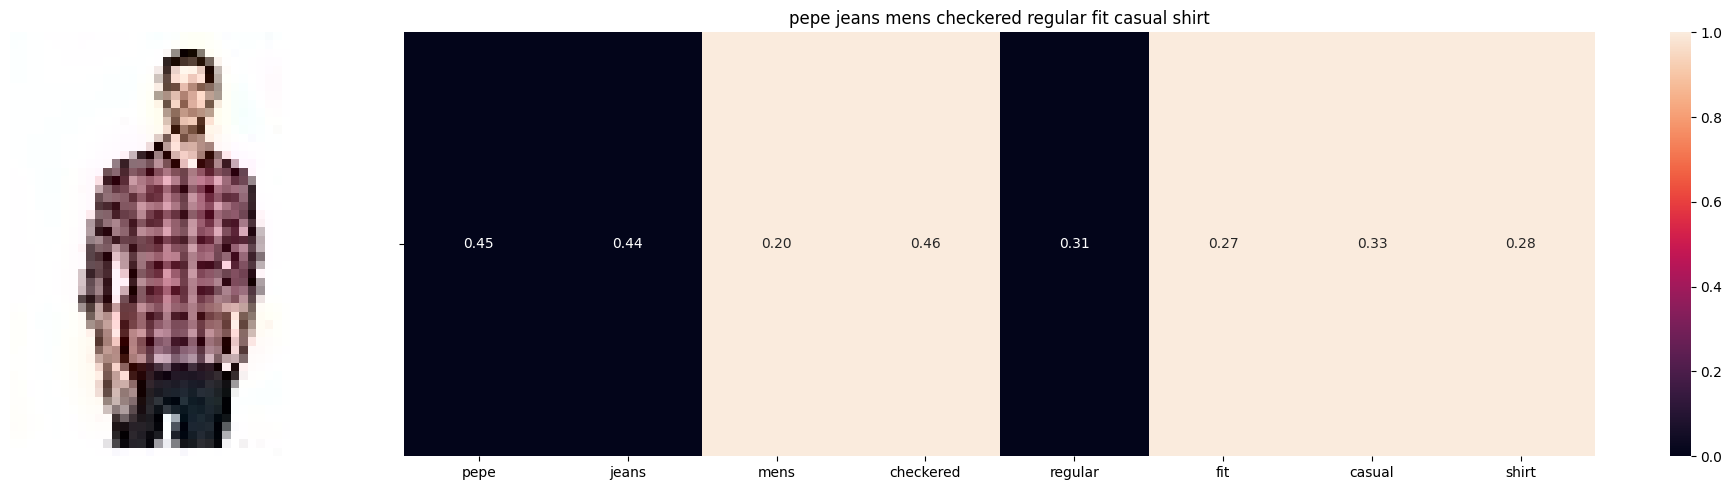

ASIN : B07FTNV8GF
BRAND : nan
Eucliden distance from the given image : 1.094817578970771


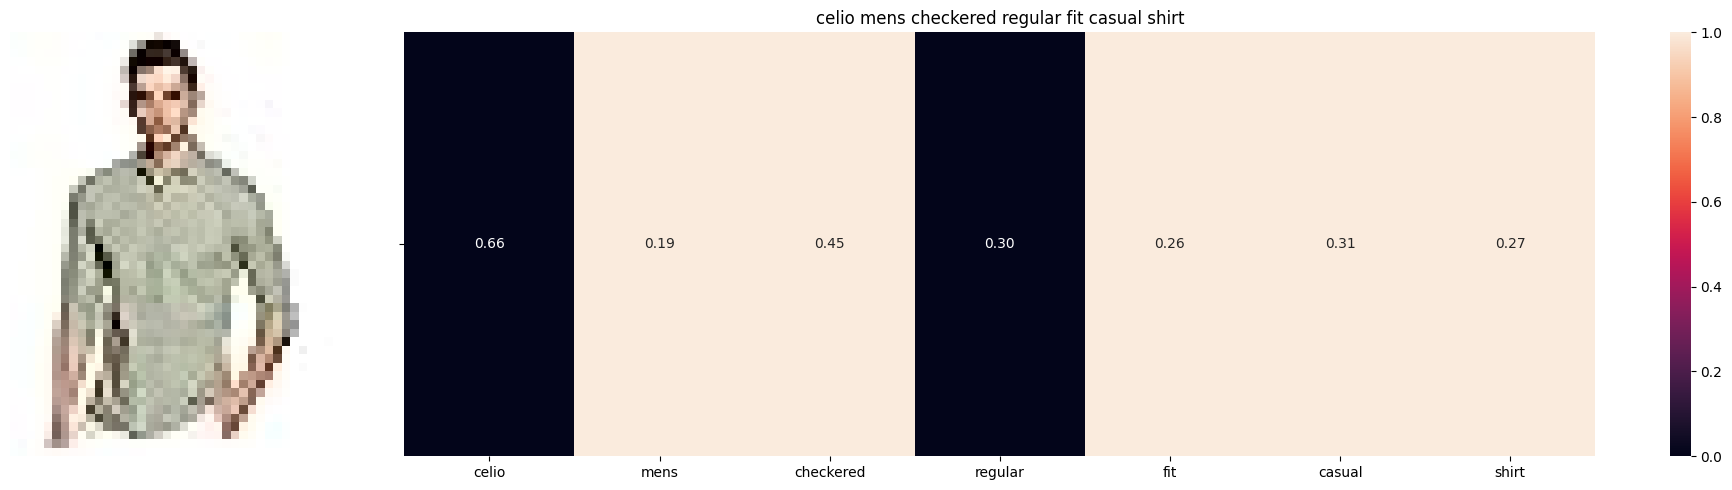

ASIN : B0811Q3XQN
BRAND : Celio
Eucliden distance from the given image : 1.1066888991542203


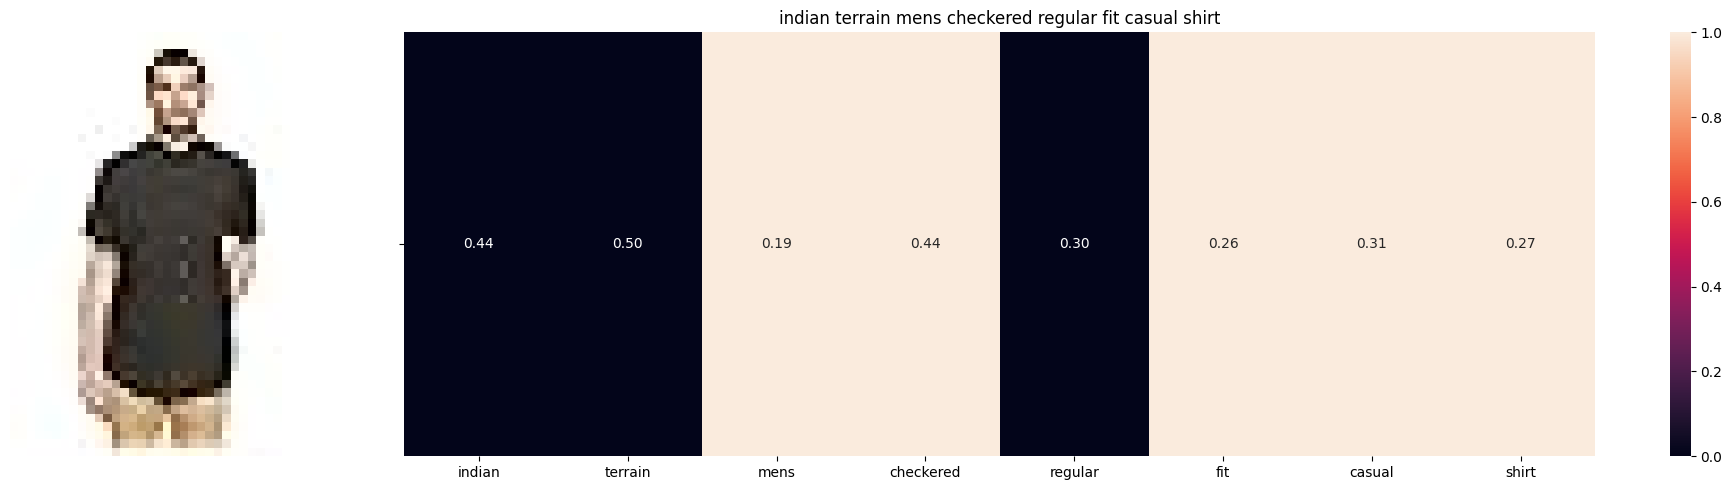

ASIN : B07FZ3XVPP
BRAND : Indian Terrain
Eucliden distance from the given image : 1.1114157454162705


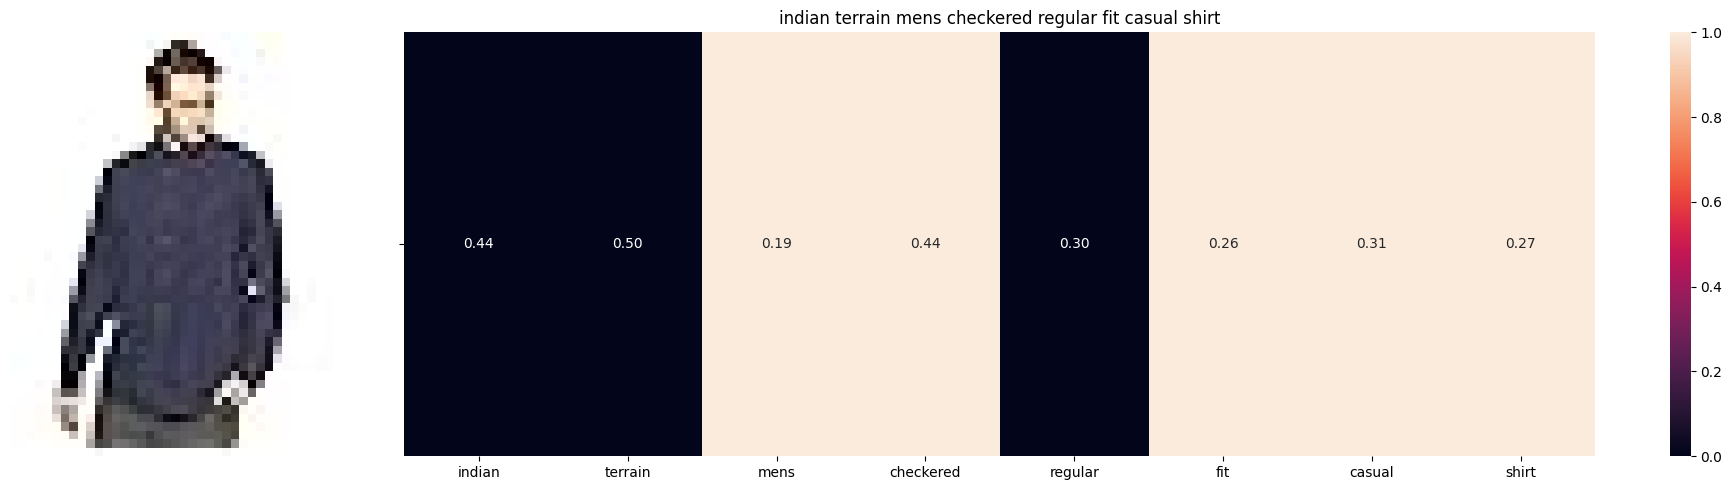

ASIN : B07FZF8Z5G
BRAND : Indian Terrain
Eucliden distance from the given image : 1.1114157454162705


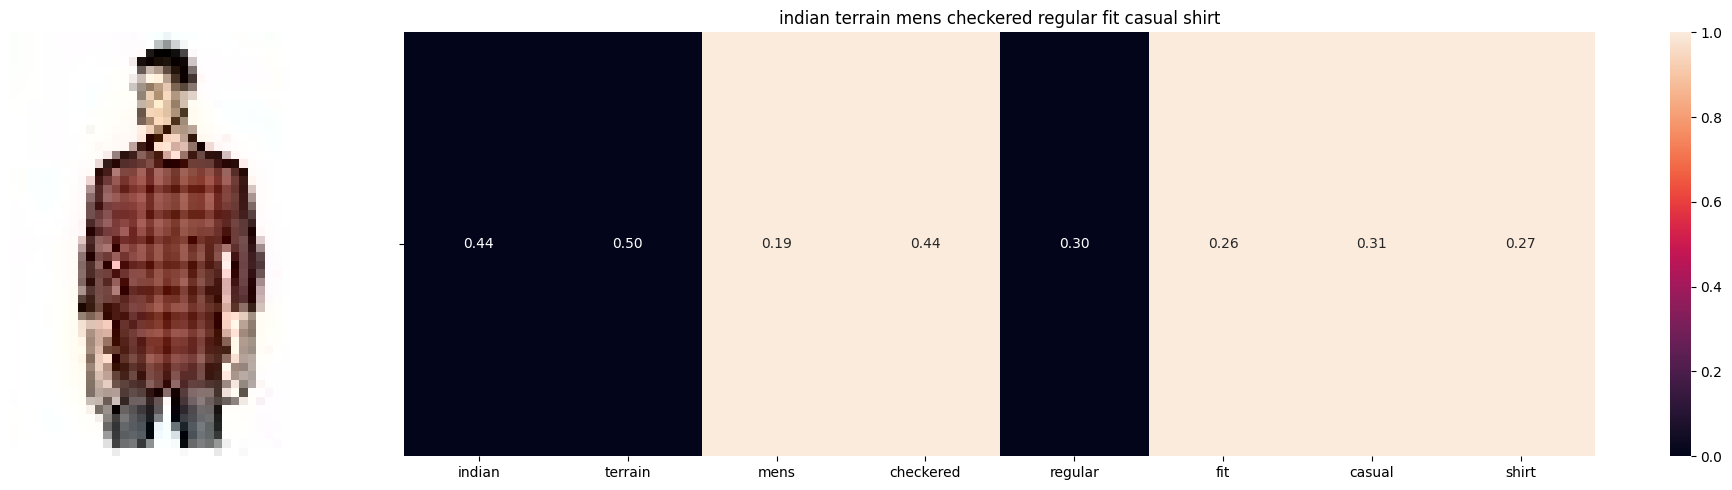

ASIN : B07FZLFS98
BRAND : Indian Terrain
Eucliden distance from the given image : 1.1114157454162705


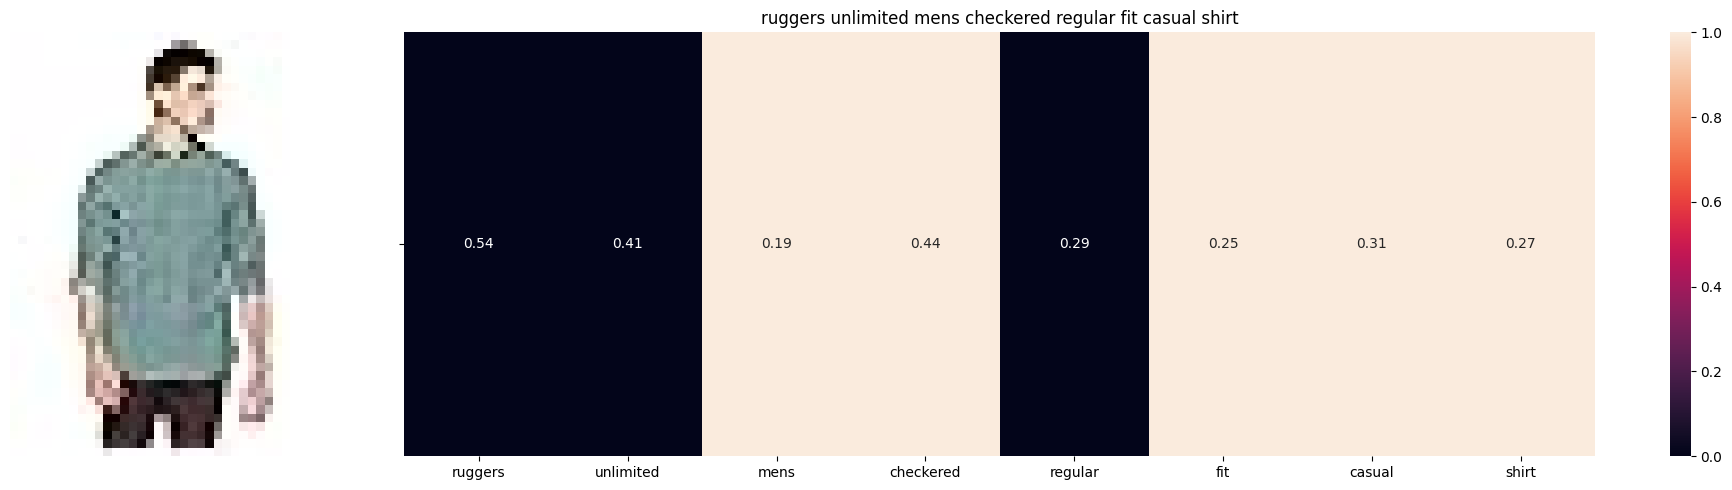

ASIN : B07DYP47HQ
BRAND : nan
Eucliden distance from the given image : 1.1146059207626342


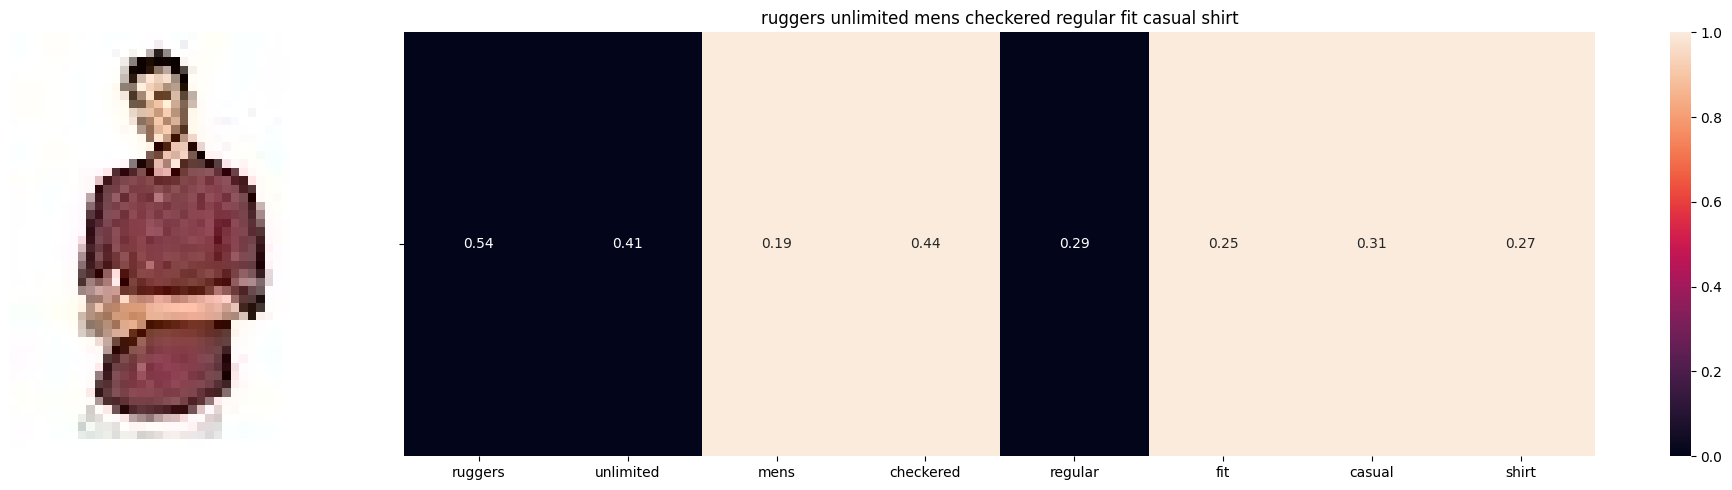

ASIN : B07DYP47KC
BRAND : nan
Eucliden distance from the given image : 1.1146059207626342


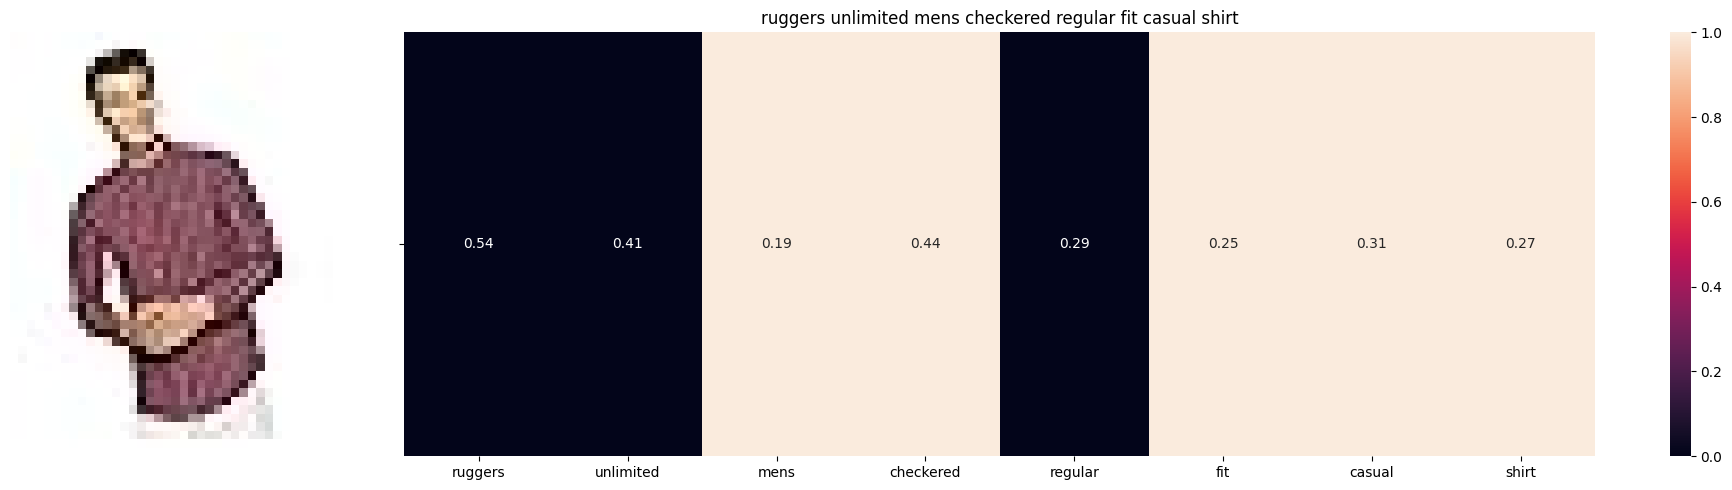

ASIN : B07DYRV13L
BRAND : nan
Eucliden distance from the given image : 1.1146059207626342


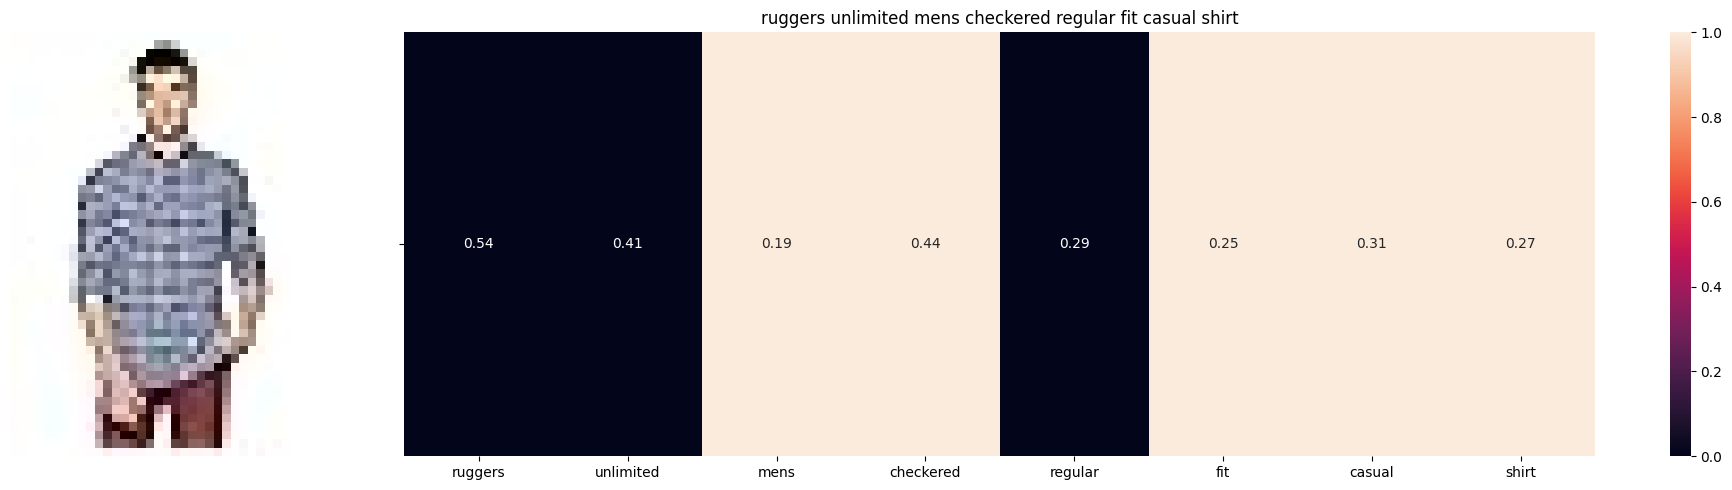

ASIN : B07DYRVBBB
BRAND : nan
Eucliden distance from the given image : 1.1146059207626342


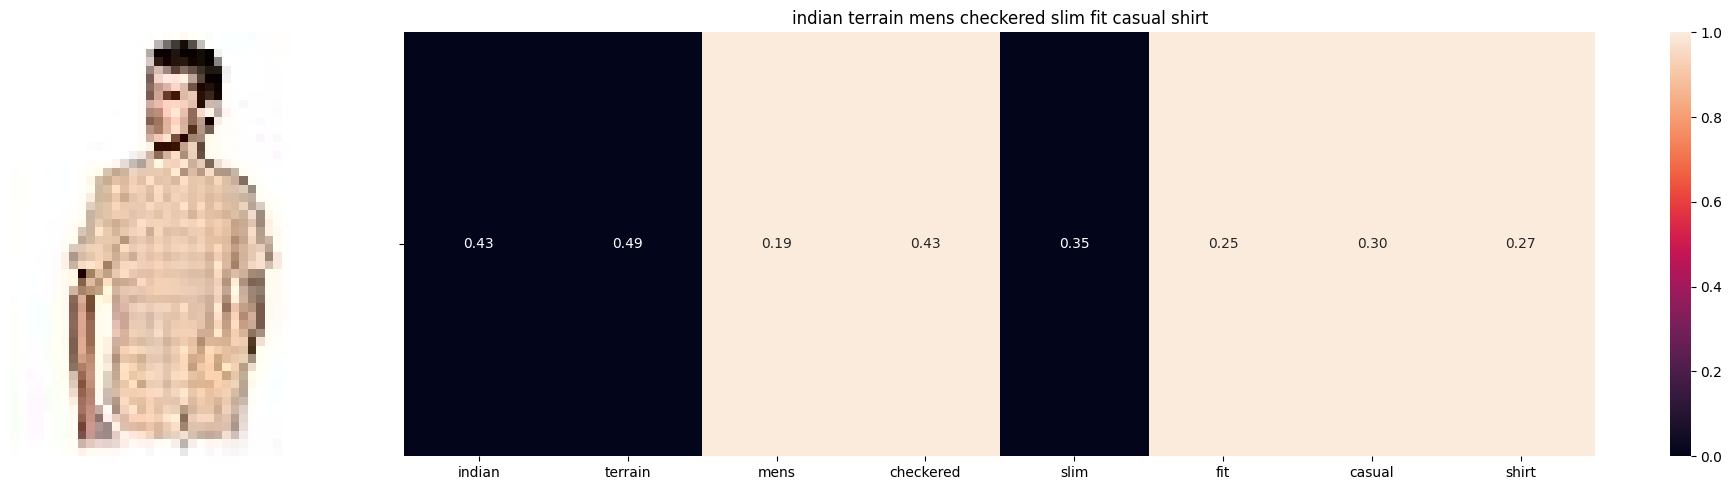

ASIN : B07D5SDP99
BRAND : Indian Terrain
Eucliden distance from the given image : 1.1179131401174622


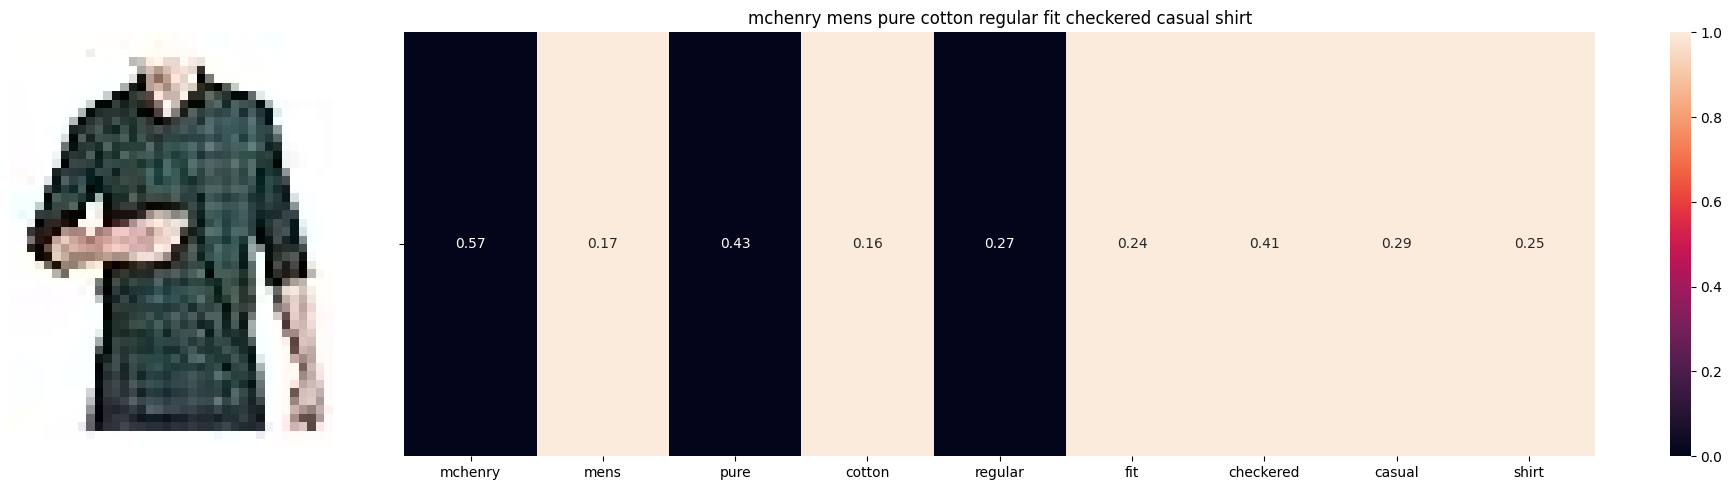

ASIN : B07BJ9NHSM
BRAND : McHenry
Eucliden distance from the given image : 1.117987274487438


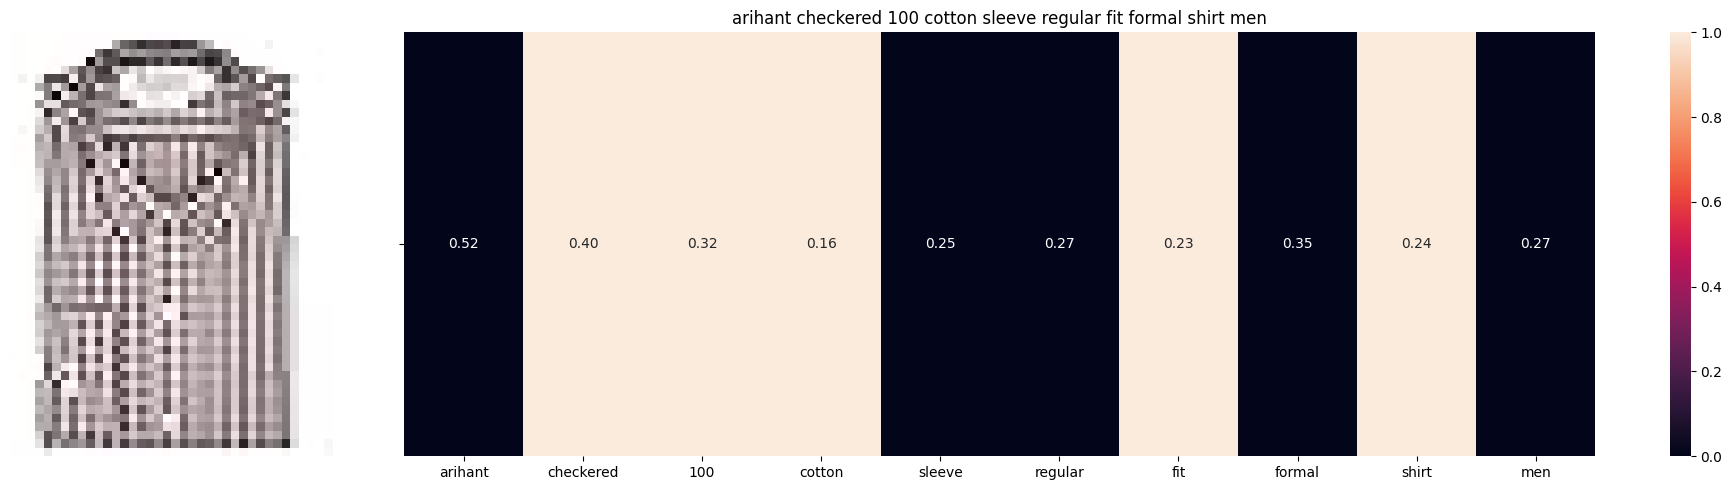

ASIN : B07VLG8325
BRAND : Arihant
Eucliden distance from the given image : 1.12774736171043


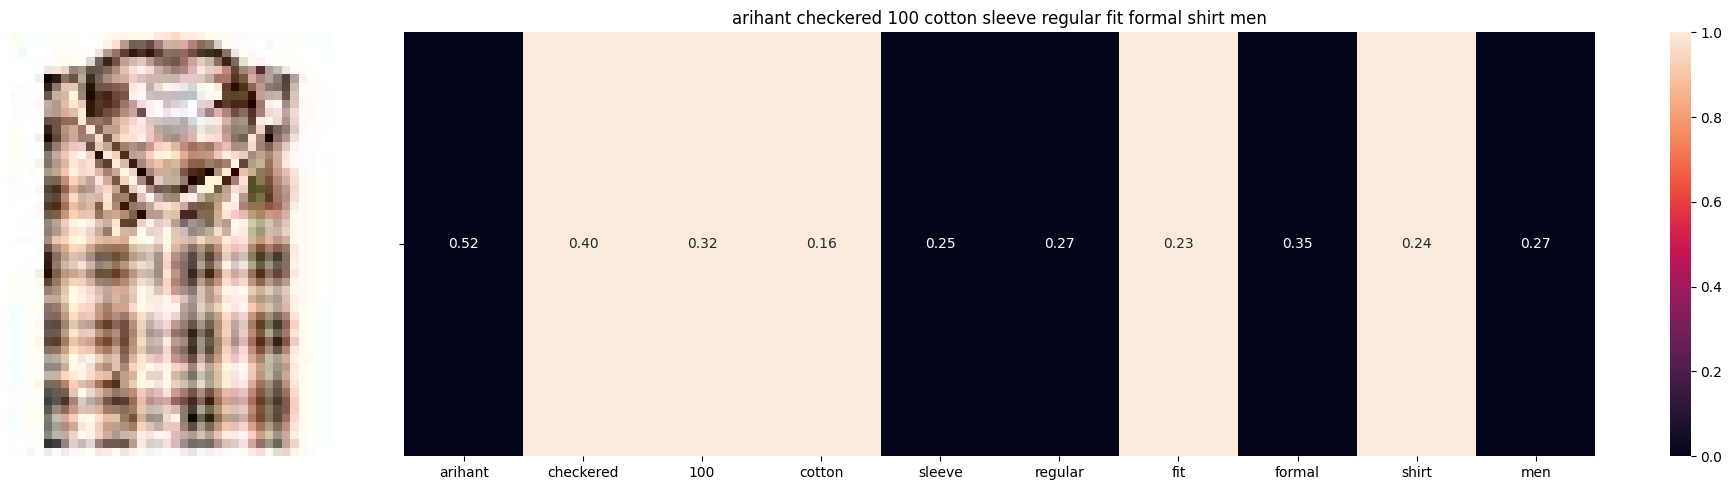

ASIN : B07VRMN8R7
BRAND : Arihant
Eucliden distance from the given image : 1.12774736171043


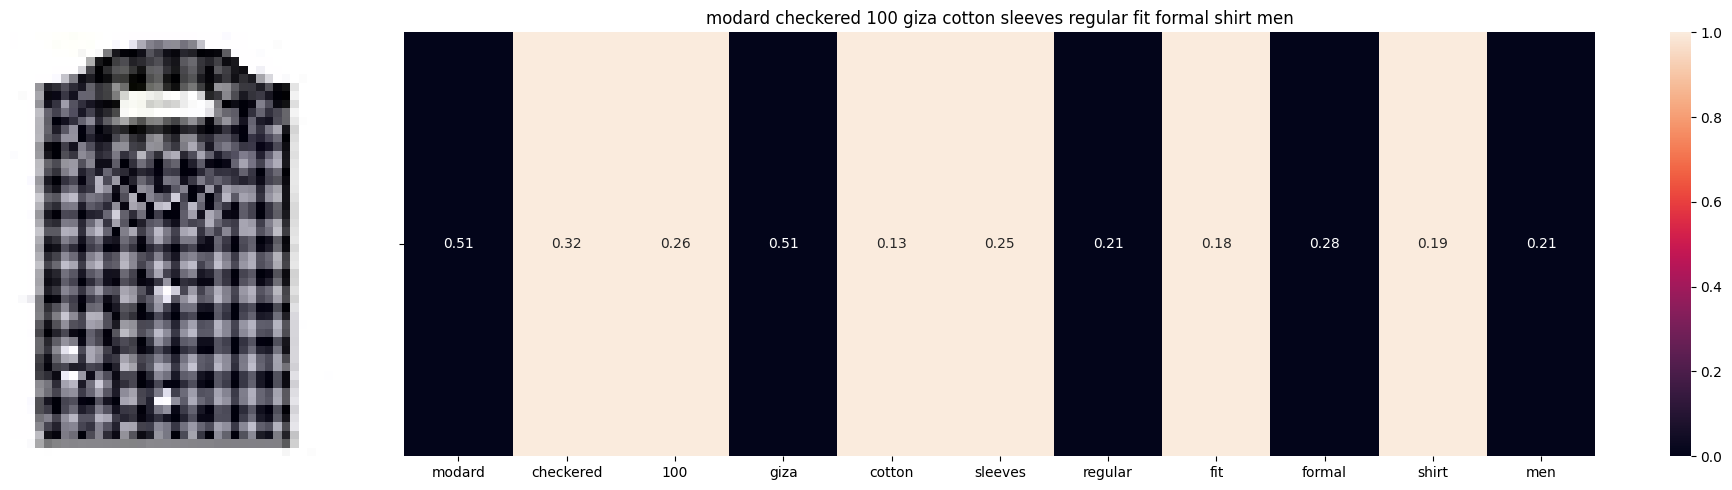

ASIN : B07YFK22MW
BRAND : MODARD
Eucliden distance from the given image : 1.1291649139243065


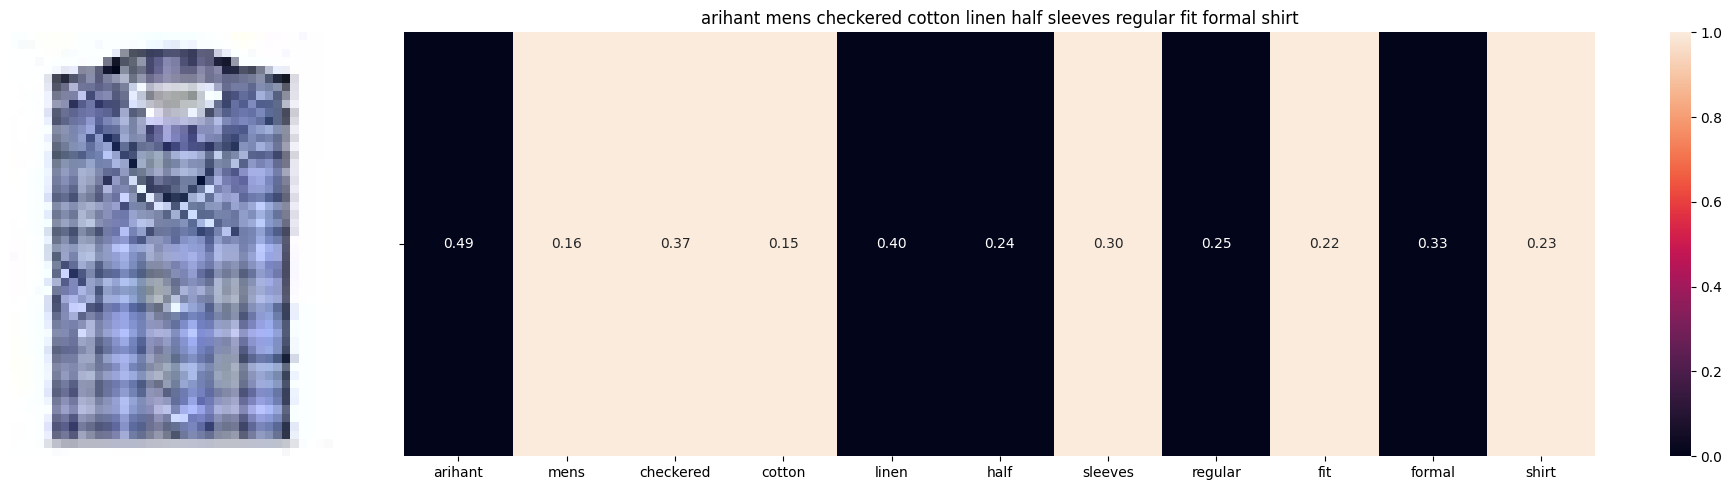

ASIN : B07PGYZ9PK
BRAND : Arihant
Eucliden distance from the given image : 1.1299987546985417


In [51]:
def tfidf_model(doc_id, num_results):
    
    
    pairwise_dist = pairwise_distances(tfidf_title_features, tfidf_title_features[doc_id])
    
    indices = np.argsort(pairwise_dist.flatten())[0:num_results]
    
    pdists = np.sort(pairwise_dist.flatten())[0:num_results]
    
    df_indices = list(data.index[indices])
    
    for i in range(0,len(indices)):
        # we will pass 1. doc_id, 2. title1, 3. title2, url, model
        get_result(indices[i], data['product_name'].loc[df_indices[0]], data['product_name'].loc[df_indices[i]], data['image_urls__small'].loc[df_indices[i]], 'tfidf')
        print('ASIN :',data['asin'].loc[df_indices[i]])
        print('BRAND :',data['brand'].loc[df_indices[i]])
        print ('Eucliden distance from the given image :', pdists[i])
        print('='*125)
    
tfidf_model(5570, 30)    

In [52]:
#corpus=['Indian cricket team will win worldcup ,says caption virat kohli','we will win next lok sabha election,says indian pm']

In [53]:
#print(corpus)

In [54]:
#from nltk.tokenize import RegexpTokenizer

#tokenizer = RegexpTokenizer(r'\w+')
#def myTokenizer(sentence):
#    words=tokenizer.tokenize(sentence.lower())
#    return filter_words(words)
#myTokenizer(corpus[0])